# Sentiment Analysis for Mental Health: DistilBERT vs BiLSTM con Explainable AI (LIME)

Questo notebook implementa un framework di Deep Learning per la classificazione e la sentiment analysis di testi legati alla salute mentale.

L'obiettivo è confrontare due approcci:
1. **Transformer (DistilBERT)**: Fine-tuning di un modello linguistico pre-addestrato basato sulla self-attention.
2. **Recurrent Neural Network (BiLSTM)**: Modello ricorrente personalizzato addestrato da zero con una rappresentazione tramite embedding.

Inoltre, utilizziamo la Explainable AI (XAI) tramite **LIME** per analizzare le parole chiave che influenzano le predizioni del modello e per comprendere le errate classificazioni.

---

## 1. Environment Setup and Library Import
Caricamento delle librerie necessarie per la manipolazione dei dati, la modellazione con PyTorch/Hugging Face e l'analisi di spiegabilità con LIME.


In [6]:

import os
import glob
import json
import re
from collections import Counter


import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, cohen_kappa_score


import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as TorchDataset 


from datasets import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer
)
import kagglehub
from lime.lime_text import LimeTextExplainer

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

Device in use: cuda


## 2. Data Acquisition and Preprocessing

Caricamento del dataset Sentiment Analysis for Mental Health (da Kaggle o locale).

### Preprocessing Step:
- **Cleaning**: Rimozione dei duplicati e dei valori nulli.
- **Label Encoding**: Conversione delle classi di testo in etichette numeriche.
- **Stratified Split**: Suddivisione in set di Train (72.25%), Validation (12.75%) e Test (15.00%), preservando il bilanciamento delle classi.


In [7]:
# Dataset paths
kaggle_path = "/kaggle/input/sentiment-analysis-for-mental-health/Combined Data.csv"
fallback_kaggle = "/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv"
local_path = "dataset/combined_data.csv"

# Load local or Kaggle dataset
if os.path.exists(kaggle_path):
    dataset_path = kaggle_path
    print("Loading from Kaggle...")
elif os.path.exists(fallback_kaggle):
    dataset_path = fallback_kaggle
    print("Loading from Kaggle (fallback)...")
elif os.path.exists(local_path):
    dataset_path = local_path
    print("Loading from local...")
else:
    print("Downloading dataset...")
    download_dir = kagglehub.dataset_download('suchintikasarkar/sentiment-analysis-for-mental-health')
    dataset_path = os.path.join(download_dir, "Combined Data.csv")

# Load and clean
df = pd.read_csv(dataset_path).dropna(subset=["statement", "status"]).drop_duplicates()

# Label encoding
le = LabelEncoder()
df["label"] = le.fit_transform(df["status"])
num_labels = df["label"].nunique()

# Train-test split (15% test)
train_val_df, test_df = train_test_split(df, test_size=0.15, stratify=df["label"], random_state=42)

# Train-validation split (15% val)
train_df, val_df = train_test_split(train_val_df, test_size=0.15, stratify=train_val_df["label"], random_state=42)

# Summary
print(f"Dimensions: Train {train_df.shape}, Val {val_df.shape}, Test {test_df.shape}")
print(f"Train Preview:\n{train_df.head()}")
print(f"\nValidation Preview:\n{val_df.head()}")
print(f"\nTest Preview:\n{test_df.head()}")

Loading from Kaggle (fallback)...
Dimensions: Train (38061, 4), Val (6717, 4), Test (7903, 4)
Train Preview:
       Unnamed: 0                                          statement  \
40108       40108  i want to die so bad and i might carry on with it   
44086       44086     hate the waiting game she hate uncertainty too   
27371       27371  If anything goes wrong, sexually, I want to ce...   
38059       38059  this week hasn t been any short of just sad i ...   
21693       21693  I am suicidal, now the fuck am i supposed to d...   

           status  label  
40108  Depression      2  
44086      Normal      3  
27371      Stress      5  
38059  Depression      2  
21693    Suicidal      6  

Validation Preview:
       Unnamed: 0                                          statement  \
10760       10760  Not sure, it will probably pass but I have bee...   
30982       30982                          why did you get divorced?   
13369       13369  all my life i had to keep going, endure,

### 2.1 Distribuzione delle Classi

Conteggio del numero di esempi per ciascuna classe (`status`) nel dataset completo e nei tre split (Train, Validation, Test), per verificare il bilanciamento e la corretta stratificazione.

Class distribution (full dataset):
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64 status
Normal                  31.02
Depression              29.24
Suicidal                20.22
Anxiety                  7.29
Bipolar                  5.27
Stress                   4.91
Personality disorder     2.04
Name: proportion, dtype: float64

Class distribution (Train set):
status
Normal                  11807
Depression              11129
Suicidal                 7696
Anxiety                  2775
Bipolar                  2006
Stress                   1869
Personality disorder      779
Name: count, dtype: int64 status
Normal                  31.02
Depression              29.24
Suicidal                20.22
Anxiety                  7.29
Bipolar                  5.27
Stress                   4.91
Personali

/tmp/ipykernel_58/2835968301.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="status", order=df["status"].value_counts().index, palette="viridis")


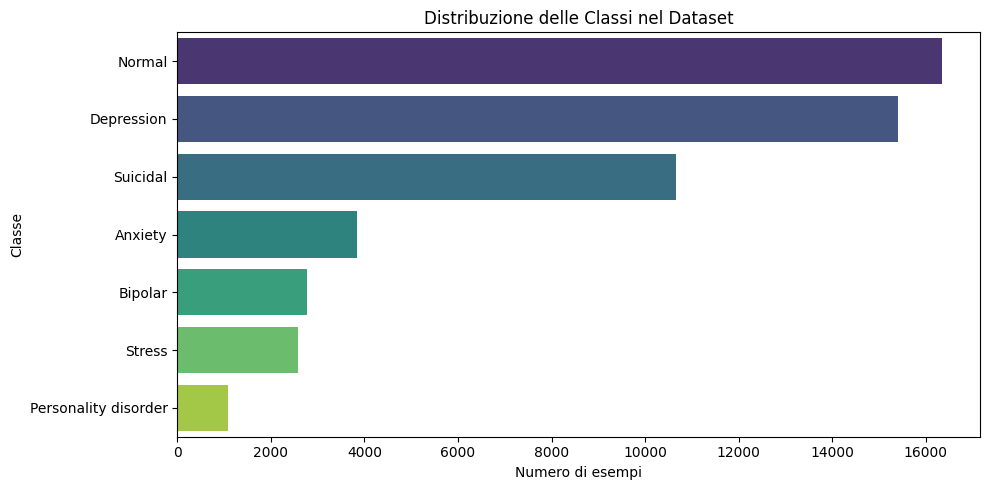

In [8]:
# Class distribution
print("Class distribution (full dataset):")
print(df["status"].value_counts(), (df["status"].value_counts(normalize=True) * 100).round(2))
print()

print("Class distribution (Train set):")
print(train_df["status"].value_counts(), (train_df["status"].value_counts(normalize=True) * 100).round(2))
print()

print("Class distribution (Validation set):")
print(val_df["status"].value_counts(), (val_df["status"].value_counts(normalize=True) * 100).round(2))
print()

print("Class distribution (Test set):")
print(test_df["status"].value_counts(), (test_df["status"].value_counts(normalize=True) * 100).round(2))

# Bar plot of class distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="status", order=df["status"].value_counts().index, palette="viridis")
plt.title("Distribuzione delle Classi nel Dataset")
plt.xlabel("Numero di esempi")
plt.ylabel("Classe")
plt.tight_layout()
plt.show()

### 2.2 Tokenization per DistilBERT

Conversione dei testi in vettori numerici utilizzando il tokenizer pre-addestrato di DistilBERT:
- **WordPiece**: Suddivisione delle parole in sotto-parole.
- **Special Token**: Inserimento dei token [CLS] e [SEP].
- **Padding e Truncation**: Standardizzazione delle sequenze a una lunghezza massima di 256 token.


In [9]:
# Tokenizer setup
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["statement"], truncation=True, padding="max_length", max_length=256)

# Tokenize HuggingFace datasets
train_ds = Dataset.from_pandas(train_df[["statement", "label"]]).map(tokenize, batched=True)
val_ds = Dataset.from_pandas(val_df[["statement", "label"]]).map(tokenize, batched=True)
test_ds = Dataset.from_pandas(test_df[["statement", "label"]]).map(tokenize, batched=True)

# Verify dimensions
print(f"Train Dataset size: {train_ds.shape}")
print(f"Val Dataset size: {val_ds.shape}")
print(f"Test Dataset size: {test_ds.shape}")

Map:   0%|          | 0/38061 [00:00<?, ? examples/s]

Map:   0%|          | 0/6717 [00:00<?, ? examples/s]

Map:   0%|          | 0/7903 [00:00<?, ? examples/s]

Train Dataset size: (38061, 6)
Val Dataset size: (6717, 6)
Test Dataset size: (7903, 6)


## 3. Model 1: Fine-tuning di DistilBERT

Inizializzazione di `AutoModelForSequenceClassification` con i pesi di `distilbert-base-uncased`.

### Configurazione del Training:
Fine-tuning eseguito utilizzando l'API `Trainer` di Hugging Face:
- Learning Rate: 5e-5
- Batch Size: 16 (train), 32 (eval)
- Epochs: 3
- Valutazione della metrica F1-Macro sul set di Validation per salvare il miglior checkpoint.


In [10]:
# Model initialization
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

# Evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Training arguments
args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True, 
)

# Trainer initialization and run
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

test_results = trainer.predict(test_ds)

# Test evaluation
print("Test Set Metrics:")
print(test_results.metrics)

final_preds = np.argmax(test_results.predictions, axis=1)
final_labels = test_results.label_ids

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, 

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.003094,0.898136,0.819116,0.801968
2,0.720645,0.822507,0.837725,0.820471
3,0.488492,0.853225,0.840852,0.823680


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Test Set Metrics:
{'test_loss': 0.8738393187522888, 'test_accuracy': 0.8329748196887258, 'test_f1_macro': 0.8189490408385113, 'test_runtime': 34.9753, 'test_samples_per_second': 225.959, 'test_steps_per_second': 3.545}


### 3.1 Inference sul Test Set con DistilBERT

Caricamento del modello migliore ed esecuzione dell'inferenza sul Test Set per estrarre le predizioni e le probabilità delle classi (tramite Softmax).


In [11]:
# Load best checkpoint
checkpoints = glob.glob("./results/checkpoint-*")
last_checkpoint = sorted(checkpoints, key=lambda x: int(x.split('-')[-1]))[-1]
model = AutoModelForSequenceClassification.from_pretrained(last_checkpoint).to(device)
model.eval()


# Setup DataLoader
test_ds_torch = test_ds.remove_columns(["statement"]).with_format("torch")
test_loader = DataLoader(test_ds_torch, batch_size=32)

all_preds, all_labels, all_probs = [], [], []

# Inference loop
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].cpu().numpy()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        
        all_preds.extend(probs.argmax(axis=1))
        all_labels.extend(labels)
        all_probs.extend(probs)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

### 3.2 Valutazione delle Performance (DistilBERT)

Calcolo del classification report (Precision, Recall, F1-Score) e visualizzazione delle matrici di confusione (valori assoluti e normalizzati).


CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             Anxiety       0.87      0.87      0.87       576
             Bipolar       0.87      0.84      0.86       417
          Depression       0.80      0.77      0.79      2311
              Normal       0.96      0.95      0.96      2452
Personality disorder       0.82      0.75      0.78       161
              Stress       0.74      0.80      0.77       388
            Suicidal       0.71      0.76      0.74      1598

            accuracy                           0.84      7903
           macro avg       0.82      0.82      0.82      7903
        weighted avg       0.84      0.84      0.84      7903



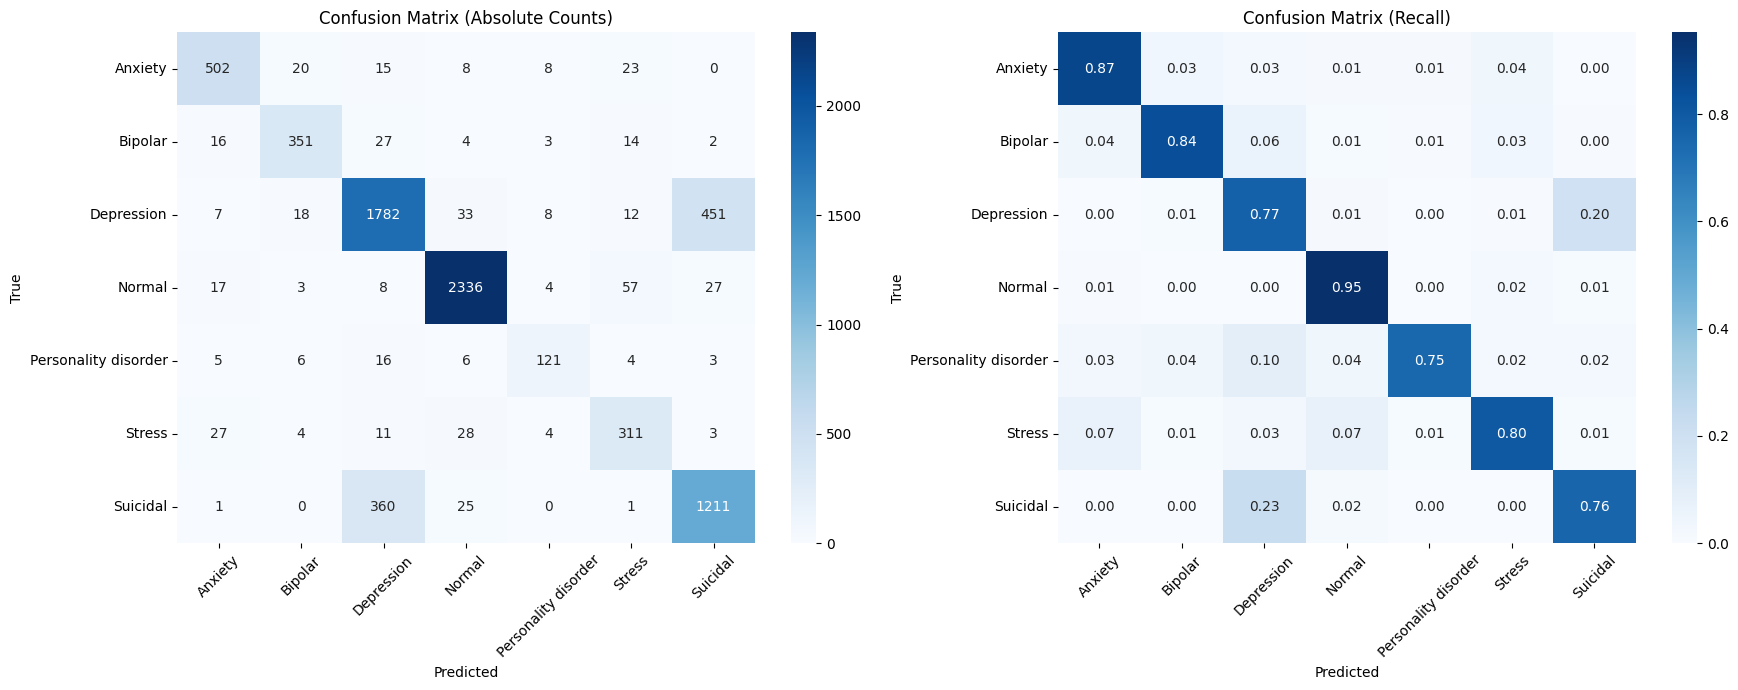

In [12]:
# Print classification report 
print("CLASSIFICATION REPORT")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# Confusion matrices
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolute count matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set(title="Confusion Matrix (Absolute Counts)", xlabel="Predicted", ylabel="True")
axes[0].tick_params(axis="x", rotation=45)

# Normalized matrix (recall)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set(title="Confusion Matrix (Recall)", xlabel="Predicted", ylabel="True")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3.3 Analisi Quantitativa degli Errori (DistilBERT)

Analisi delle errate classificazioni del modello sul Test Set, con focus sugli errori ad alta confidenza (predizioni errate con probabilità superiore all'80%) e sulle coppie di classi confuse più frequentemente.


In [13]:
# Filter misclassifications
# Create evaluation DataFrame
df_eval = pd.DataFrame({
    "text": test_df["statement"].reset_index(drop=True),
    "true": le.inverse_transform(all_labels),
    "pred_bert": le.inverse_transform(all_preds),
    "confidence": all_probs.max(axis=1)
})

# Get errors
wrong_mask = df_eval["pred_bert"] != df_eval["true"]
df_errors = df_eval[wrong_mask].sort_values("confidence", ascending=False)

print(f"Incorrect examples: {len(df_errors)} / {len(df_eval)} ({100 * len(df_errors)/len(df_eval):.1f}%)\n")

# Show top 10 high-confidence errors
print("\nHigh-confidence errors\n\n")
for _, row in df_errors.head(10).iterrows():
    print(f"Text      : {row['text'][:250]}")
    print(f"True      : {row['true']:<15} Predicted: {row['pred_bert']:<15} Confidence: {row['confidence']:.1%}\n")

# Print error frequencies
print("\n\nERROR FREQUENCY SUMMARY\n\n")
error_summary = df_errors.groupby(["true", "pred_bert"]).size().sort_values(ascending=False).head(10)
print(error_summary)

Incorrect examples: 1289 / 7903 (16.3%)


High-confidence errors


Text      : DANIEL WON!
True      : Suicidal        Predicted: Normal          Confidence: 99.8%

Text      : Vai exam eto kharap hoice
True      : Anxiety         Predicted: Normal          Confidence: 99.8%

Text      : Good Sign This is Tennacious. He's my first flower of spring and he bloomed on my first day in my new home.
True      : Bipolar         Predicted: Normal          Confidence: 99.7%

Text      : god im stupid
True      : Depression      Predicted: Normal          Confidence: 99.6%

Text      : Bruh The awkward moment between birth and death
True      : Depression      Predicted: Normal          Confidence: 99.6%

Text      : i have a small business we got a meeting with our biggest client ever and i called them by their competitor name i m so scared i cost u the deal
True      : Depression      Predicted: Normal          Confidence: 99.6%

Text      : looking for 90+ rated players for our pro clubs team

In [14]:
# Print error examples 
num_example = 2

def print_examples(df_filtrato, title):
    if df_filtrato.empty:
        print(f"\n{title}: No examples found")
        return
    
    # Sample examples
    n_sample = min(len(df_filtrato), num_example)
    
    # Random sample
    df_sample = df_filtrato.sample(n=n_sample, random_state=42)
    
    print(f"\n{title}")
    for _, row in df_sample.iterrows():
        print(f"Confidence: {row['confidence']:.1%} | TRUE: {row['true']} | PREDICTED: {row['pred_bert']}")
        print(f"TEXT: {row['text'][:200]}...")
        print()

# Initialize empty DataFrames
df_top_error = pd.DataFrame()
df_fn = pd.DataFrame()
df_high_conf_errors = pd.DataFrame()

if not df_errors.empty:
    # Top error scenario
    top_error_pair = df_errors.groupby(['true', 'pred_bert']).size().idxmax()
    df_top_error = df_errors[(df_errors['true'] == top_error_pair[0]) & (df_errors['pred_bert'] == top_error_pair[1])]
    print_examples(df_top_error, f"Frequent error: {top_error_pair[0]} -> {top_error_pair[1]}")

    # False negatives (Pathology -> Normal)
    fn_mask = (df_errors['true'] != 'Normal') & (df_errors['pred_bert'] == 'Normal')
    df_fn = df_errors[fn_mask]
    print_examples(df_fn, "False Negatives (Pathology classified as 'Normal')")

    # High-confidence errors (>80%)
    df_high_conf_errors = df_errors[df_errors['confidence'] > 0.80]
    print_examples(df_high_conf_errors, "High-Confidence Errors > 80%")
else:
    print("No errors found in the test dataset.")


Frequent error: Depression -> Suicidal
Confidence: 65.6% | TRUE: Depression | PREDICTED: Suicidal
TEXT: Right now I feel passively suicidal. I do not feel like trying to kill myself, but I strongly hope I do not wake up the next day. I wish I was dead, but I do not have any plans in mind. I absolutely h...

Confidence: 89.6% | TRUE: Depression | PREDICTED: Suicidal
TEXT: Maybe I want to end it... Maybe I do not. But if I do what is the fastest way to go? Fastest way?...


False Negatives (Pathology classified as 'Normal')
Confidence: 90.8% | TRUE: Stress | PREDICTED: Normal
TEXT: She humiliates me in front of other people and when we're alone. I'm always just a servant who's there to get her drinks and hype her up. I'm always just the butt of her jokes. She used to invite me o...

Confidence: 71.5% | TRUE: Depression | PREDICTED: Normal
TEXT: I was thinking of getting a cat or a dog to take care of, do they help? Does a pet really help?...


High-Confidence Errors > 80%
Confidence: 86

### 3.4 Spiegabilità con LIME per DistilBERT

Applicazione di LIME (Local Interpretable Model-agnostic Explanations) per interpretare le predizioni di DistilBERT nei casi di errore più comuni. LIME evidenzia il contributo positivo o negativo di ciascun token rispetto alla decisione del classificatore.



LIME ANALYSIS: HOTSPOT ERROR

Analysis -> TRUE: Depression | PREDICTED: Suicidal | Conf: 95.5%
  Hang                 ▲ INCREASES prob. (+0.1495)
  Myself               ▲ INCREASES prob. (+0.1380)
  I                    ▲ INCREASES prob. (+0.0797)
  here                 ▲ INCREASES prob. (+0.0678)
  seconds              ▲ INCREASES prob. (+0.0572)
  like                 ▲ INCREASES prob. (+0.0534)
  and                  ▲ INCREASES prob. (+0.0481)
  them                 ▲ INCREASES prob. (+0.0440)
  accept               ▼ DECREASES prob. (-0.0140)
  To                   ▼ DECREASES prob. (-0.0135)


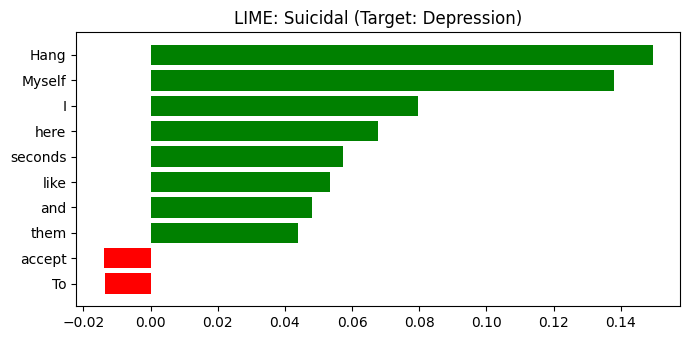


Analysis -> TRUE: Depression | PREDICTED: Suicidal | Conf: 94.8%
  pills                ▲ INCREASES prob. (+0.1626)
  fuck                 ▲ INCREASES prob. (+0.0931)
  am                   ▲ INCREASES prob. (+0.0927)
  I                    ▲ INCREASES prob. (+0.0816)
  cigarettes           ▲ INCREASES prob. (+0.0736)
  and                  ▲ INCREASES prob. (+0.0567)
  return               ▲ INCREASES prob. (+0.0524)
  tonight              ▲ INCREASES prob. (+0.0506)
  night                ▼ DECREASES prob. (-0.0183)
  the                  ▼ DECREASES prob. (-0.0167)


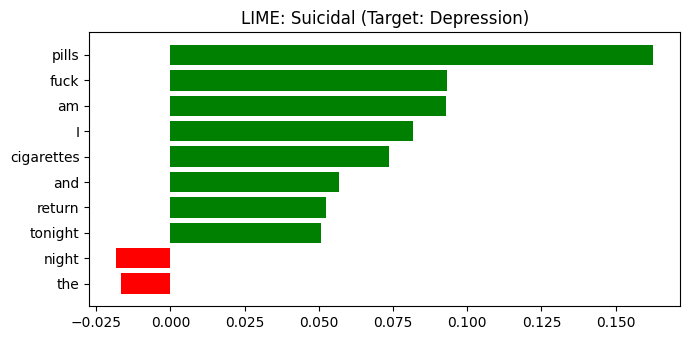


LIME ANALYSIS: FALSI NEGATIVI

Analysis -> TRUE: Suicidal | PREDICTED: Normal | Conf: 99.8%
  DANIEL               ▲ INCREASES prob. (+0.0009)
  WON                  ▲ INCREASES prob. (+0.0003)


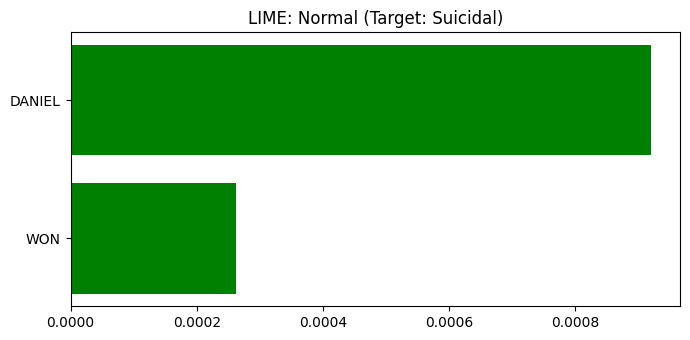


Analysis -> TRUE: Anxiety | PREDICTED: Normal | Conf: 99.8%
  kharap               ▲ INCREASES prob. (+0.0024)
  Vai                  ▲ INCREASES prob. (+0.0022)
  hoice                ▲ INCREASES prob. (+0.0020)
  eto                  ▼ DECREASES prob. (-0.0011)
  exam                 ▼ DECREASES prob. (-0.0004)


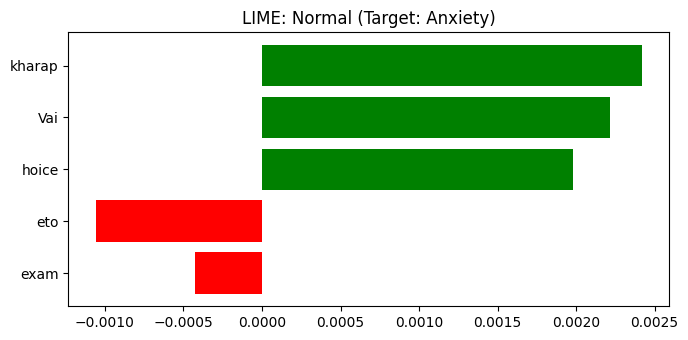


LIME ANALYSIS: ALTA CONFIDENZA (>80%)

Analysis -> TRUE: Suicidal | PREDICTED: Normal | Conf: 99.8%
  DANIEL               ▲ INCREASES prob. (+0.0009)
  WON                  ▲ INCREASES prob. (+0.0002)


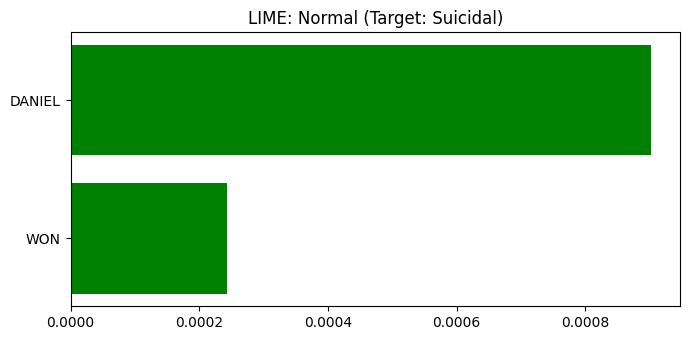


Analysis -> TRUE: Anxiety | PREDICTED: Normal | Conf: 99.8%
  kharap               ▲ INCREASES prob. (+0.0027)
  hoice                ▲ INCREASES prob. (+0.0024)
  Vai                  ▲ INCREASES prob. (+0.0021)
  eto                  ▼ DECREASES prob. (-0.0013)
  exam                 ▼ DECREASES prob. (-0.0009)


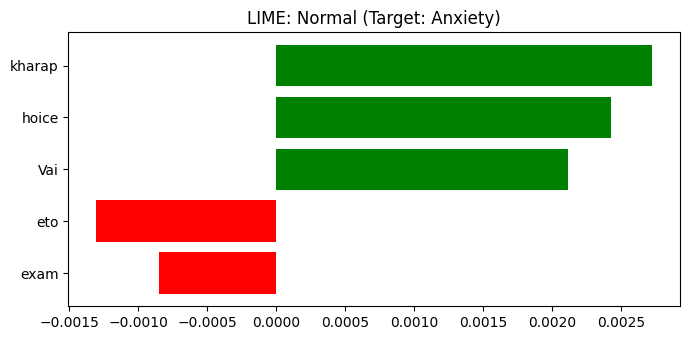

In [15]:
# Define analysis categories
categories_to_analyze = [ 
    (df_top_error, "HOTSPOT ERROR"),
    (df_fn, "FALSI NEGATIVI"),
    (df_high_conf_errors, "ALTA CONFIDENZA (>80%)")
]

# Prediction wrapper for LIME
def predict_proba_fn(texts):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=256)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    return torch.softmax(outputs.logits, dim=1).cpu().numpy()

lime_explainer = LimeTextExplainer(class_names=le.classes_)

# LIME loop
for df_source, category_name in categories_to_analyze:
    if df_source.empty:
        print(f"\n{category_name}: No data to analyze")
        continue
        
    print(f"\nLIME ANALYSIS: {category_name}")
    
    # Explain top examples
    for _, row in df_source.head(num_example).iterrows():
        text = row['text']
        true_label = row['true']
        pred_label = row['pred_bert']
        
        try:
            print(f"\nAnalysis -> TRUE: {true_label} | PREDICTED: {pred_label} | Conf: {row['confidence']:.1%}")
            
            # Target class index
            pred_idx = np.where(le.classes_ == pred_label)[0][0]
            
            exp = lime_explainer.explain_instance(
                text, predict_proba_fn, num_features=10, num_samples=300, labels=(pred_idx,)
            )

            # Print feature importances
            for word, weight in exp.as_list(label=pred_idx):
                direction = "▲ INCREASES prob." if weight > 0 else "▼ DECREASES prob."
                print(f"  {word:<20} {direction} ({weight:+.4f})")

            # Plot explanation
            fig = exp.as_pyplot_figure(label=pred_idx)
            fig.set_size_inches(7, 3.5)
            plt.title(f"LIME: {pred_label} (Target: {true_label})")
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"LIME error for this example: {e}")


## 4. Model 2: Custom Bidirectional LSTM (BiLSTM)

Definizione di un modello ricorrente personalizzato (BiLSTM) in PyTorch.

### Tokenization Pipeline e Vocabolario:
- **simple_tokenize**: Tokenizzazione basata su regex e conversione in minuscolo.
- **Vocabolario**: Costruito sulla base di una frequenza minima (MIN_FREQ=2), gestendo gli special token `<PAD>` e `<UNK>`.


In [16]:
# Custom tokenizer
def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

# Vocabulary builder 
MIN_FREQ = 2
MAX_LEN_LSTM = 256
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

counter = Counter()
for text in train_df["statement"]:
    counter.update(simple_tokenize(text))

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)

# Vocabulary info
print(f"Vocabulary size: {VOCAB_SIZE:,} words")
print(f"Max fixed sequence length: {MAX_LEN_LSTM}")

Vocabulary size: 25,063 words
Max fixed sequence length: 256


### 4.1 PyTorch Dataset e DataLoader per BiLSTM

Definizione della classe `TextDataset` per codificare i testi e standardizzare la lunghezza delle sequenze a 256. Configurazione dei relativi `DataLoader` con un batch size di 64.


In [17]:
# Custom PyTorch Dataset
class TextDataset(TorchDataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def _encode(self, text):
        tokens = simple_tokenize(text)[:self.max_len]
        ids = [self.vocab.get(t, 1) for t in tokens]
        ids += [0] * (self.max_len - len(ids))
        return ids

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return ( 
            torch.tensor(self._encode(self.texts[idx]), dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

# Prepare numpy arrays
train_texts_arr = train_df["statement"].values
val_texts_arr = val_df["statement"].values
test_texts_arr = test_df["statement"].values 

train_labels_arr = train_df["label"].values
val_labels_arr = val_df["label"].values
test_labels_arr = test_df["label"].values 

BATCH_SIZE_LSTM = 64

# Instantiate datasets
train_dataset_lstm = TextDataset(train_texts_arr, train_labels_arr, vocab, MAX_LEN_LSTM)
val_dataset_lstm = TextDataset(val_texts_arr, val_labels_arr, vocab, MAX_LEN_LSTM)
test_dataset_lstm = TextDataset(test_texts_arr, test_labels_arr, vocab, MAX_LEN_LSTM)

# Instantiate DataLoaders
train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE_LSTM, shuffle=True)
val_loader_lstm = DataLoader(val_dataset_lstm, batch_size=BATCH_SIZE_LSTM)
test_loader_lstm = DataLoader(test_dataset_lstm, batch_size=BATCH_SIZE_LSTM) 

# Dataset summary
print(f"Train: {len(train_dataset_lstm)} samples, {len(train_loader_lstm)} batches")
print(f"Val: {len(val_dataset_lstm)} samples, {len(val_loader_lstm)} batches")
print(f"Test: {len(test_dataset_lstm)} samples, {len(test_loader_lstm)} batches")

Train: 38061 samples, 595 batches
Val: 6717 samples, 105 batches
Test: 7903 samples, 124 batches


### 4.2 Definizione del Modello BiLSTM e Training Loop

Architettura del classificatore BiLSTM:
- **Embedding Layer**: Spazio a 128 dimensioni.
- **BiLSTM**: Concatenazione degli stati nascosti forward e backward (512 dimensioni totali).
- **Dropout**: Regolarizzazione (tasso 0.3).
- **Linear Classifier**: Output sui logit delle classi.

Training per 10 epoche con ottimizzatore AdamW e ReduceLROnPlateau.


In [18]:
# BiLSTM Classifier model
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.classifier(self.dropout(last_hidden))

# Hyperparameters and setup
EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT = 128, 256, 2, 0.3
NUM_EPOCHS_LSTM, LR_LSTM = 10, 1e-3
device_lstm = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lstm_model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS, num_classes=num_labels, dropout=DROPOUT
).to(device_lstm)

optimizer = optim.AdamW(lstm_model.parameters(), lr=LR_LSTM, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
criterion = nn.CrossEntropyLoss()

os.makedirs("./results_lstm", exist_ok=True)
best_f1_lstm, best_epoch_lstm, history_lstm = 0.0, 0, []

print(f"Trainable parameters: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")
print(f"Epoch | Train Loss | Val Loss | Accuracy | F1 Macro")

# Training loop
for epoch in range(1, NUM_EPOCHS_LSTM + 1):
    lstm_model.train()
    train_loss = 0.0
    for input_ids, labels in train_loader_lstm:
        input_ids, labels = input_ids.to(device_lstm), labels.to(device_lstm)
        optimizer.zero_grad()
        logits = lstm_model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader_lstm)

    lstm_model.eval()
    val_loss, epoch_preds, epoch_true = 0.0, [], []
    with torch.no_grad():
        for input_ids, labels in val_loader_lstm:
            input_ids, labels = input_ids.to(device_lstm), labels.to(device_lstm)
            logits = lstm_model(input_ids)
            val_loss += criterion(logits, labels).item()
            epoch_preds.extend(logits.argmax(dim=1).cpu().numpy())
            epoch_true.extend(labels.cpu().numpy())

    val_loss /= len(val_loader_lstm)
    acc = accuracy_score(epoch_true, epoch_preds)
    f1mac = f1_score(epoch_true, epoch_preds, average="macro")
    history_lstm.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "accuracy": acc, "f1_macro": f1mac})
    scheduler.step(f1mac)

    marker = " best" if f1mac > best_f1_lstm else ""
    print(f"{epoch:5} | {train_loss:10.4f} | {val_loss:8.4f} | {acc:8.4f} | {f1mac:8.4f}{marker}")

    if f1mac > best_f1_lstm:
        best_f1_lstm = f1mac
        best_epoch_lstm = epoch
        torch.save(lstm_model.state_dict(), "./results_lstm/best_model.pt")

print(f"Best F1 Macro: {best_f1_lstm:.4f} at epoch {best_epoch_lstm}")

Trainable parameters: 5,579,143
Epoch | Train Loss | Val Loss | Accuracy | F1 Macro
    1 |     1.0694 |   1.0290 |   0.6229 |   0.4366 best
    2 |     0.7804 |   0.6880 |   0.7302 |   0.6158 best
    3 |     0.6427 |   0.6028 |   0.7608 |   0.6995 best
    4 |     0.5527 |   0.5699 |   0.7739 |   0.7140 best
    5 |     0.4945 |   0.5560 |   0.7817 |   0.7389 best
    6 |     0.4414 |   0.5385 |   0.7910 |   0.7520 best
    7 |     0.3983 |   0.5497 |   0.7925 |   0.7526 best
    8 |     0.3609 |   0.5523 |   0.7971 |   0.7568 best
    9 |     0.3252 |   0.5699 |   0.7987 |   0.7627 best
   10 |     0.2948 |   0.6015 |   0.7877 |   0.7530
Best F1 Macro: 0.7627 at epoch 9


### 4.3 Curve di Apprendimento (BiLSTM)

Visualizzazione delle curve di Loss (Train vs Val) e della metrica F1-Macro lungo le epoche per valutare la convalida del modello BiLSTM.


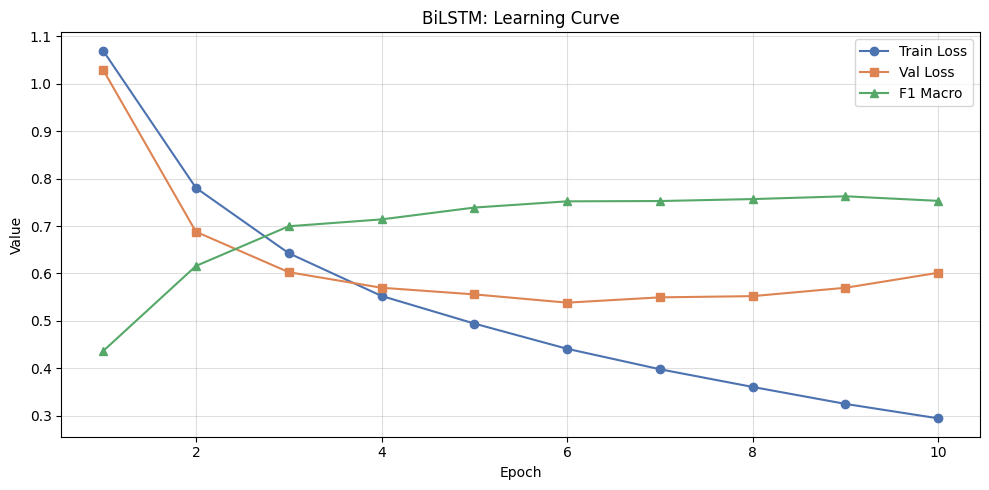

In [19]:
# Plot learning curves

epochs_x = [h["epoch"] for h in history_lstm]
train_losses = [h["train_loss"] for h in history_lstm]
val_losses = [h["val_loss"] for h in history_lstm]
f1_macros = [h["f1_macro"] for h in history_lstm]

plt.figure(figsize=(10, 5))
plt.plot(epochs_x, train_losses, "o-", label="Train Loss", color="#4C72B0")
plt.plot(epochs_x, val_losses, "s-", label="Val Loss", color="#DD8452")
plt.plot(epochs_x, f1_macros, "^-", label="F1 Macro", color="#55A868")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("BiLSTM: Learning Curve")
plt.legend()
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

### 4.4 Inference e Valutazione sul Test Set (BiLSTM)

Caricamento dei pesi migliori ed esecuzione dell'inferenza sul Test Set. Stampa del report delle metriche e visualizzazione delle matrici di confusione.


BILSTM CLASSIFICATION REPORT (TEST SET)
                      precision    recall  f1-score   support

             Anxiety       0.88      0.78      0.83       576
             Bipolar       0.86      0.79      0.83       417
          Depression       0.73      0.74      0.74      2311
              Normal       0.92      0.95      0.94      2452
Personality disorder       0.62      0.65      0.63       161
              Stress       0.68      0.59      0.63       388
            Suicidal       0.69      0.71      0.70      1598

            accuracy                           0.80      7903
           macro avg       0.77      0.74      0.76      7903
        weighted avg       0.80      0.80      0.79      7903



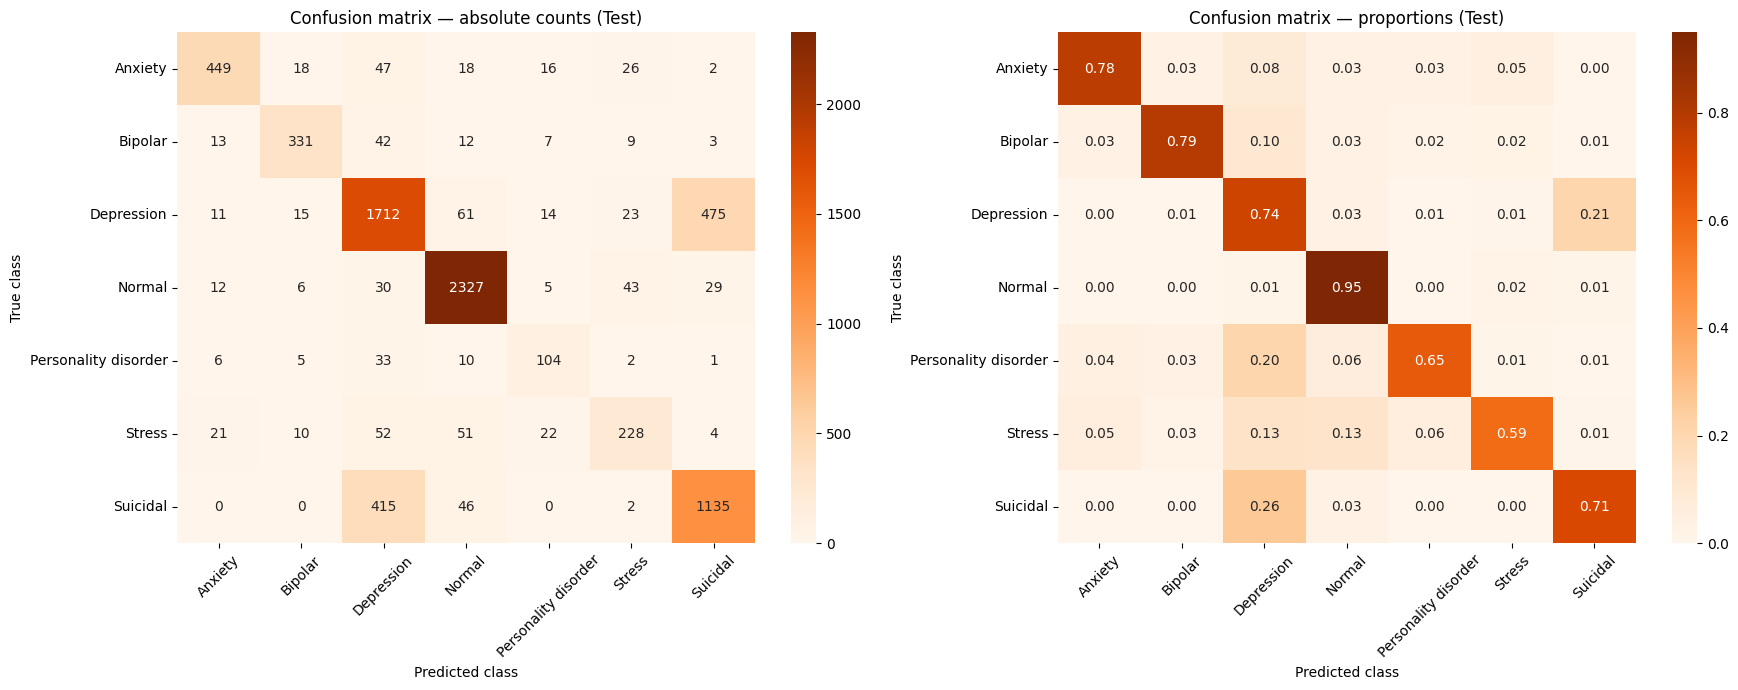

In [20]:
# Load best weights
lstm_model.load_state_dict(torch.load("./results_lstm/best_model.pt", map_location=device_lstm))
lstm_model.eval()

# Infer on test set
lstm_preds_all, lstm_labels_all, lstm_probs_all = [], [], []

with torch.no_grad():
    for input_ids, labels in test_loader_lstm:
        input_ids = input_ids.to(device_lstm)
        logits = lstm_model(input_ids)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        
        # Save to global variables
        lstm_preds_all.extend(probs.argmax(axis=1))
        lstm_labels_all.extend(labels.numpy())
        lstm_probs_all.extend(probs)

# Convert to numpy arrays
lstm_preds_all = np.array(lstm_preds_all)
lstm_labels_all = np.array(lstm_labels_all)
lstm_probs_all = np.array(lstm_probs_all)

# Print report
print("BILSTM CLASSIFICATION REPORT (TEST SET)")
print(classification_report(lstm_labels_all, lstm_preds_all, target_names=le.classes_))

# Plot confusion matrices
cm_lstm = confusion_matrix(lstm_labels_all, lstm_preds_all)
cm_lstm_norm = cm_lstm.astype(float) / cm_lstm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title("Confusion matrix — absolute counts (Test)")
axes[0].set_ylabel("True class")
axes[0].set_xlabel("Predicted class")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cm_lstm_norm, annot=True, fmt=".2f", cmap="Oranges",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title("Confusion matrix — proportions (Test)")
axes[1].set_ylabel("True class")
axes[1].set_xlabel("Predicted class")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 4.5 Analisi Quantitativa degli Errori (BiLSTM)

Identificazione dei falsi negativi e delle errate classificazioni ad alta confidenza per il modello BiLSTM sul Test Set.


In [21]:
df_lstm_eval = pd.DataFrame({
    "text": test_texts_arr, # Make sure this is the original text array
    "true": le.inverse_transform(lstm_labels_all),
    "pred_lstm": le.inverse_transform(lstm_preds_all),
    "confidence": lstm_probs_all.max(axis=1)
})

# Get errors
wrong_mask_lstm = df_lstm_eval["true"] != df_lstm_eval["pred_lstm"]
df_errors_lstm = df_lstm_eval[wrong_mask_lstm].sort_values("confidence", ascending=False)

print(f"Incorrect examples (BiLSTM): {len(df_errors_lstm)} / {len(df_lstm_eval)} ({100 * len(df_errors_lstm)/len(df_lstm_eval):.1f}%)\n")

# Show top 10 high-confidence errors
print("\nHigh-confidence BiLSTM errors\n")
for _, row in df_errors_lstm.head(10).iterrows():
    print(f"Text      : {row['text'][:250]}")
    print(f"True      : {row['true']:<15} Predicted: {row['pred_lstm']:<15} Confidence: {row['confidence']:.1%}\n")

# Print error frequencies
print("\n\nERROR FREQUENCY SUMMARY (BiLSTM)\n")
lstm_error_summary = df_errors_lstm.groupby(["true", "pred_lstm"]).size().sort_values(ascending=False).head(10)
print(lstm_error_summary)

Incorrect examples (BiLSTM): 1617 / 7903 (20.5%)


High-confidence BiLSTM errors

Text      : i d rather not exist
True      : Depression      Predicted: Normal          Confidence: 100.0%

Text      : Happy | Energetic Music For Peace music to destress to. ENJOY
True      : Stress          Predicted: Normal          Confidence: 100.0%

Text      :  let us make a Wikipedia page for PSSD!
True      : Depression      Predicted: Normal          Confidence: 100.0%

Text      : What is your top 3 songs alltime? My 3 are Hammock Sinking inside yourself(saved my life)😊 Hammock procession/Love in the void&amp;Hammock Dissonance❤️
True      : Personality disorder Predicted: Normal          Confidence: 100.0%

Text      : preferably without becoming addicted
True      : Depression      Predicted: Normal          Confidence: 100.0%

Text      : Head pressure, dry eye &amp; anxiety I’ve been posting my journey for the last 2 years as these symptoms came on abruptly and to this day have never left.

In [22]:
num_example = 2

def print_examples_lstm(df_filtrato, title):
    if df_filtrato.empty:
        print(f"\n{title}: No examples found")
        return
    
    # Random sample
    n_sample = min(len(df_filtrato), num_example)
    df_sample = df_filtrato.sample(n=n_sample, random_state=42)
    
    print(f"\n{title}")
    for _, row in df_sample.iterrows():
        print(f"Confidence: {row['confidence']:.1%} | TRUE: {row['true']} | PREDICTED: {row['pred_lstm']}")
        print(f"TEXT: {row['text'][:200]}...")
        print()

# Prepare BiLSTM errors
df_errors_lstm = df_lstm_eval[df_lstm_eval['true'] != df_lstm_eval['pred_lstm']]

if not df_errors_lstm.empty:
    # Top error scenario
    top_error_pair = df_errors_lstm.groupby(['true', 'pred_lstm']).size().idxmax()
    df_top_error = df_errors_lstm[(df_errors_lstm['true'] == top_error_pair[0]) & (df_errors_lstm['pred_lstm'] == top_error_pair[1])]
    print_examples_lstm(df_top_error, f"Frequent error (BiLSTM): {top_error_pair[0]} -> {top_error_pair[1]}")

    # False negatives (Pathology -> Normal)
    fn_mask = (df_errors_lstm['true'] != 'Normal') & (df_errors_lstm['pred_lstm'] == 'Normal')
    df_fn_lstm = df_errors_lstm[fn_mask]
    print_examples_lstm(df_fn_lstm, "False Negatives (Pathology classified as 'Normal')")

    # High-confidence errors (>80%)
    df_high_conf_errors_lstm = df_errors_lstm[df_errors_lstm['confidence'] > 0.80]
    print_examples_lstm(df_high_conf_errors_lstm, "High-Confidence Errors > 80% (BiLSTM)")
else:
    print("No errors found in the test dataset for the BiLSTM model.")


Frequent error (BiLSTM): Depression -> Suicidal
Confidence: 78.9% | TRUE: Depression | PREDICTED: Suicidal
TEXT: After getting "fake" heartbroken today over a "obsessive fantasy" I had with a guy and learning he has a girlfriend, I realised that all my previous trying has led to nothing but misery. I go to work ...

Confidence: 63.7% | TRUE: Depression | PREDICTED: Suicidal
TEXT: my whole fucking life has been full of mental and physical abuse ever since i was a kid weird shit has been happening. been abused by my moms bf for 15 years after my dad left from doing something tha...


False Negatives (Pathology classified as 'Normal')
Confidence: 60.3% | TRUE: Suicidal | PREDICTED: Normal
TEXT: Fake news just went ballistic. Get ready.                                 You thought fake news was bad? Deep fakesâ¦ https://t.co/LnXcyfRktk...

Confidence: 98.8% | TRUE: Depression | PREDICTED: Normal
TEXT: no reason in life...


High-Confidence Errors > 80% (BiLSTM)
Confidence: 93.2% | TRUE: S

### 4.6 Analisi LIME per BiLSTM

Applicazione di LIME sul modello BiLSTM per analizzare l'importanza locale delle parole e confrontare la logica decisionale con quella del Transformer.



LIME ANALYSIS: HOTSPOT ERROR (BiLSTM)

Analysis -> TRUE: Depression | PREDICTED: Suicidal | Conf: 54.8%
  kill                 ▲ INCREASES prob. (+0.1782)
  Sometimes            ▼ DECREASES prob. (-0.1401)
  just                 ▼ DECREASES prob. (-0.0672)
  failed               ▲ INCREASES prob. (+0.0665)
  school               ▼ DECREASES prob. (-0.0622)
  myself               ▼ DECREASES prob. (-0.0591)
  sit                  ▼ DECREASES prob. (-0.0591)
  I                    ▼ DECREASES prob. (-0.0587)
  here                 ▲ INCREASES prob. (+0.0565)
  and                  ▲ INCREASES prob. (+0.0417)


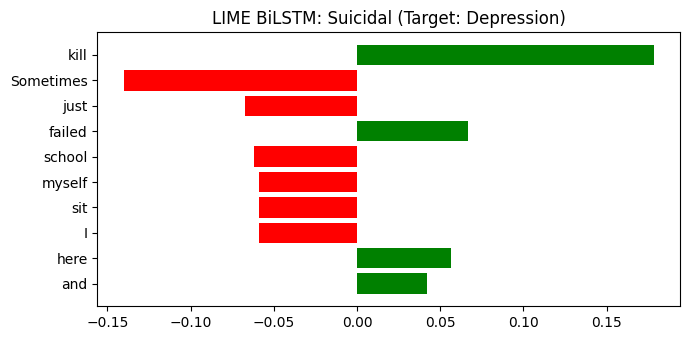


Analysis -> TRUE: Depression | PREDICTED: Suicidal | Conf: 72.3%
  end                  ▲ INCREASES prob. (+0.2730)
  i                    ▲ INCREASES prob. (+0.1686)
  all                  ▲ INCREASES prob. (+0.1635)
  wish                 ▲ INCREASES prob. (+0.1351)
  is                   ▲ INCREASES prob. (+0.0941)
  worse                ▲ INCREASES prob. (+0.0883)
  way                  ▲ INCREASES prob. (+0.0857)
  to                   ▼ DECREASES prob. (-0.0656)
  could                ▲ INCREASES prob. (+0.0536)
  getting              ▲ INCREASES prob. (+0.0507)


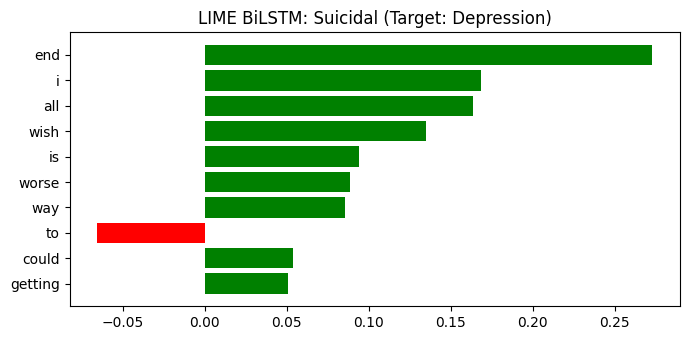


LIME ANALYSIS: FALSI NEGATIVI (BiLSTM)

Analysis -> TRUE: Suicidal | PREDICTED: Normal | Conf: 54.3%
  RT                   ▼ DECREASES prob. (-0.3039)
  life                 ▼ DECREASES prob. (-0.1739)
  looks                ▲ INCREASES prob. (+0.1012)
  real                 ▼ DECREASES prob. (-0.0863)
  to                   ▼ DECREASES prob. (-0.0360)
  myonlyTAEger         ▼ DECREASES prob. (-0.0240)
  like                 ▼ DECREASES prob. (-0.0226)
  V                    ▼ DECREASES prob. (-0.0118)
  Knets                ▼ DECREASES prob. (-0.0109)
  try                  ▲ INCREASES prob. (+0.0088)


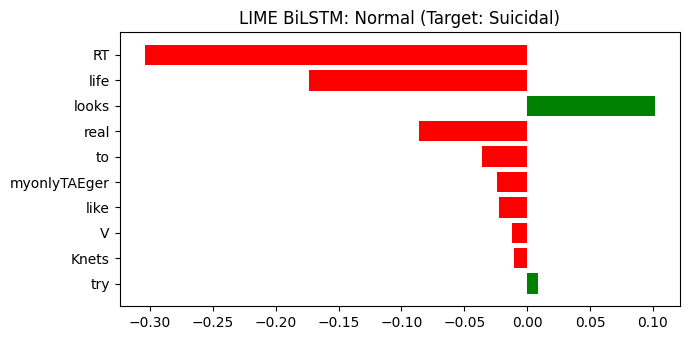


Analysis -> TRUE: Depression | PREDICTED: Normal | Conf: 71.7%
  This                 ▼ DECREASES prob. (-0.1095)
  me                   ▼ DECREASES prob. (-0.0904)
  pain                 ▼ DECREASES prob. (-0.0872)
  feeling              ▼ DECREASES prob. (-0.0794)
  the                  ▲ INCREASES prob. (+0.0785)
  Benjamin             ▲ INCREASES prob. (+0.0759)
  If                   ▲ INCREASES prob. (+0.0589)
  just                 ▼ DECREASES prob. (-0.0537)
  is                   ▼ DECREASES prob. (-0.0486)
  I                    ▼ DECREASES prob. (-0.0454)


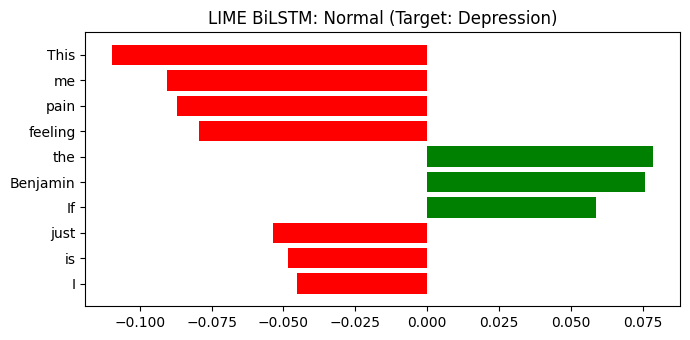


LIME ANALYSIS: ALTA CONFIDENZA >80% (BiLSTM)

Analysis -> TRUE: Suicidal | PREDICTED: Depression | Conf: 98.6%
  i                    ▲ INCREASES prob. (+0.1900)
  just                 ▲ INCREASES prob. (+0.1857)
  do                   ▲ INCREASES prob. (+0.1357)
  my                   ▲ INCREASES prob. (+0.1177)
  not                  ▲ INCREASES prob. (+0.1154)
  favourite            ▲ INCREASES prob. (+0.1061)
  watch                ▲ INCREASES prob. (+0.0992)
  day                  ▲ INCREASES prob. (+0.0865)
  words                ▼ DECREASES prob. (-0.0597)
  from                 ▼ DECREASES prob. (-0.0268)


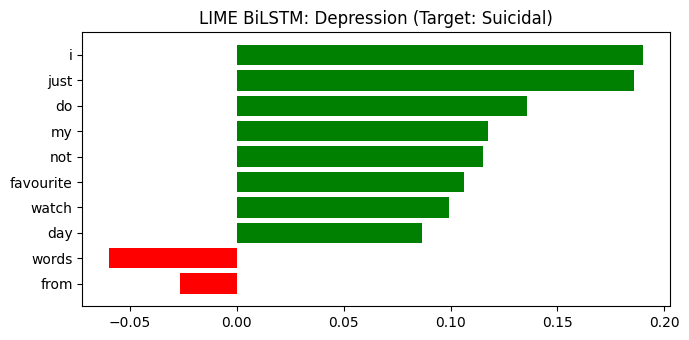


Analysis -> TRUE: Stress | PREDICTED: Anxiety | Conf: 87.0%
  worry                ▲ INCREASES prob. (+0.4404)
  worried              ▲ INCREASES prob. (+0.2520)
  anxiety              ▲ INCREASES prob. (+0.1732)
  I                    ▲ INCREASES prob. (+0.1629)
  and                  ▼ DECREASES prob. (-0.1543)
  times                ▲ INCREASES prob. (+0.1285)
  to                   ▼ DECREASES prob. (-0.1081)
  m                    ▼ DECREASES prob. (-0.1045)
  her                  ▼ DECREASES prob. (-0.0967)
  constantly           ▼ DECREASES prob. (-0.0754)


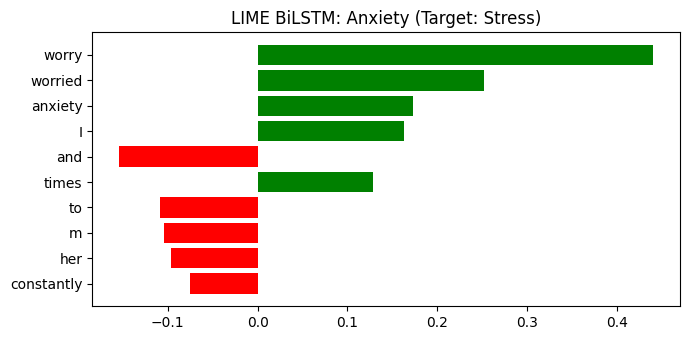

In [23]:
# Define analysis categories
categories_to_analyze = [
    (df_top_error, "HOTSPOT ERROR (BiLSTM)"),
    (df_fn_lstm, "FALSI NEGATIVI (BiLSTM)"),
    (df_high_conf_errors_lstm, "ALTA CONFIDENZA >80% (BiLSTM)")
]

# Prediction wrapper for LIME
def lstm_predict_proba(texts):
    # LIME input is a list of strings
    lstm_model.eval()
    all_probs = []
    
    # Batch processing
    for i in range(0, len(texts), 32):
        batch = texts[i:i + 32]
        encoded = []
        for text in batch:
            tokens = simple_tokenize(str(text))[:MAX_LEN_LSTM]
            ids = [vocab.get(t, 1) for t in tokens]
            ids += [0] * (MAX_LEN_LSTM - len(ids))
            encoded.append(ids)
        
        tensor = torch.tensor(encoded, dtype=torch.long).to(device_lstm)
        with torch.no_grad():
            probs = torch.softmax(lstm_model(tensor), dim=1).cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

lime_explainer_lstm = LimeTextExplainer(class_names=le.classes_)

# LIME loop
for df_source, category_name in categories_to_analyze:
    if df_source.empty:
        print(f"\n{category_name}: No data to analyze")
        continue
        
    print(f"\nLIME ANALYSIS: {category_name}")
    
    # Explain top examples
    for _, row in df_source.head(num_example).iterrows():
        text = row['text']
        true_label = row['true']
        pred_label = row['pred_lstm']
        confidence = row['confidence']
        
        try:
            print(f"\nAnalysis -> TRUE: {true_label} | PREDICTED: {pred_label} | Conf: {confidence:.1%}")
            
            # Target class index
            pred_idx = np.where(le.classes_ == pred_label)[0][0]
            
            exp = lime_explainer_lstm.explain_instance(
                text, lstm_predict_proba, num_features=10, num_samples=300, labels=(pred_idx,)
            )

            # Print feature importances
            for word, weight in exp.as_list(label=pred_idx):
                direction = "▲ INCREASES prob." if weight > 0 else "▼ DECREASES prob."
                print(f"  {word:<20} {direction} ({weight:+.4f})")

            # Plot explanation
            fig = exp.as_pyplot_figure(label=pred_idx)
            fig.set_size_inches(7, 3.5)
            plt.title(f"LIME BiLSTM: {pred_label} (Target: {true_label})")
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"LIME error for this example: {e}")

## 5. Analisi Comparativa: DistilBERT vs BiLSTM

Confronto diretto tra le due architetture:
1. **Model Agreement**: Calcolo del coefficiente Kappa di Cohen per misurare l'allineamento delle predizioni.
2. **Scenari di Classificazione**: Classificazione dei campioni in base alle prestazioni dei due modelli (es. entrambi corretti, meglio BERT, meglio LSTM).
3. **Spiegazioni LIME Affiancate**: Confronto visivo delle parole chiave estratte per entrambi i modelli sullo stesso testo.


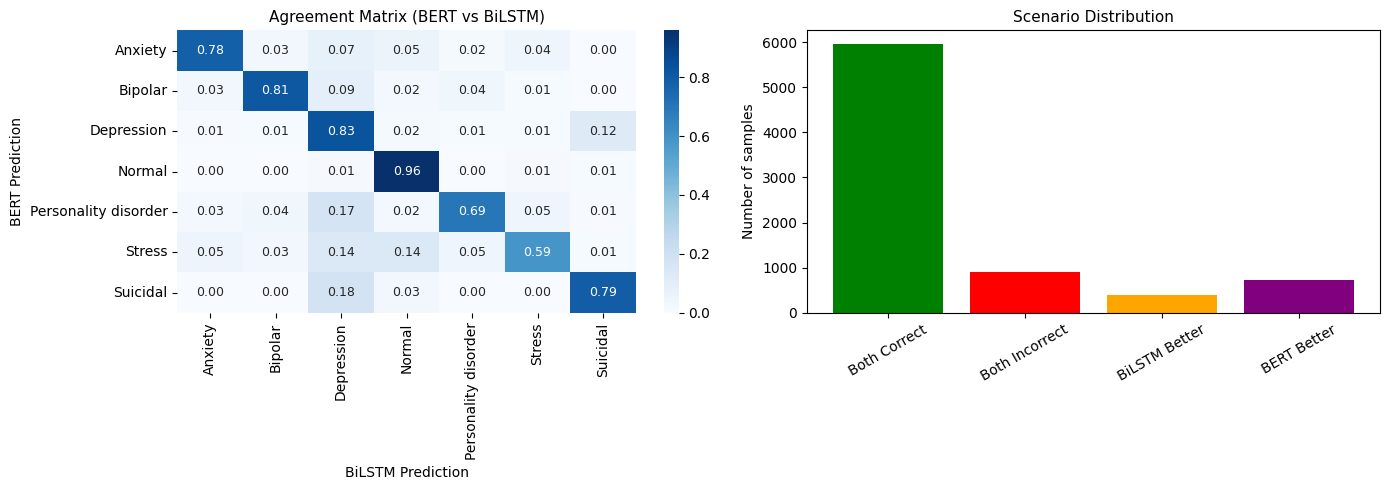


Agreement coefficient (Cohen's Kappa): 0.7917

SCENARIO: Both Correct
TEXT: cherrytreerec oh man i can t see the vid it ot available in my country...
TRUE: Normal | BERT: Normal | BiLSTM: Normal

LIME BERT
  i                    ▼ DECREASES prob. (-0.0029)
  cherrytreerec        ▲ INCREASES prob. (+0.0024)
  vid                  ▲ INCREASES prob. (+0.0020)
  see                  ▲ INCREASES prob. (+0.0017)
  the                  ▲ INCREASES prob. (+0.0017)
  man                  ▲ INCREASES prob. (+0.0016)
  ot                   ▲ INCREASES prob. (+0.0015)
  oh                   ▲ INCREASES prob. (+0.0014)
  in                   ▲ INCREASES prob. (+0.0013)
  it                   ▼ DECREASES prob. (-0.0011)

LIME BiLSTM
  oh                   ▲ INCREASES prob. (+0.0020)
  available            ▼ DECREASES prob. (-0.0019)
  the                  ▲ INCREASES prob. (+0.0016)
  in                   ▲ INCREASES prob. (+0.0015)
  see                  ▲ INCREASES prob. (+0.0012)
  cherrytreerec

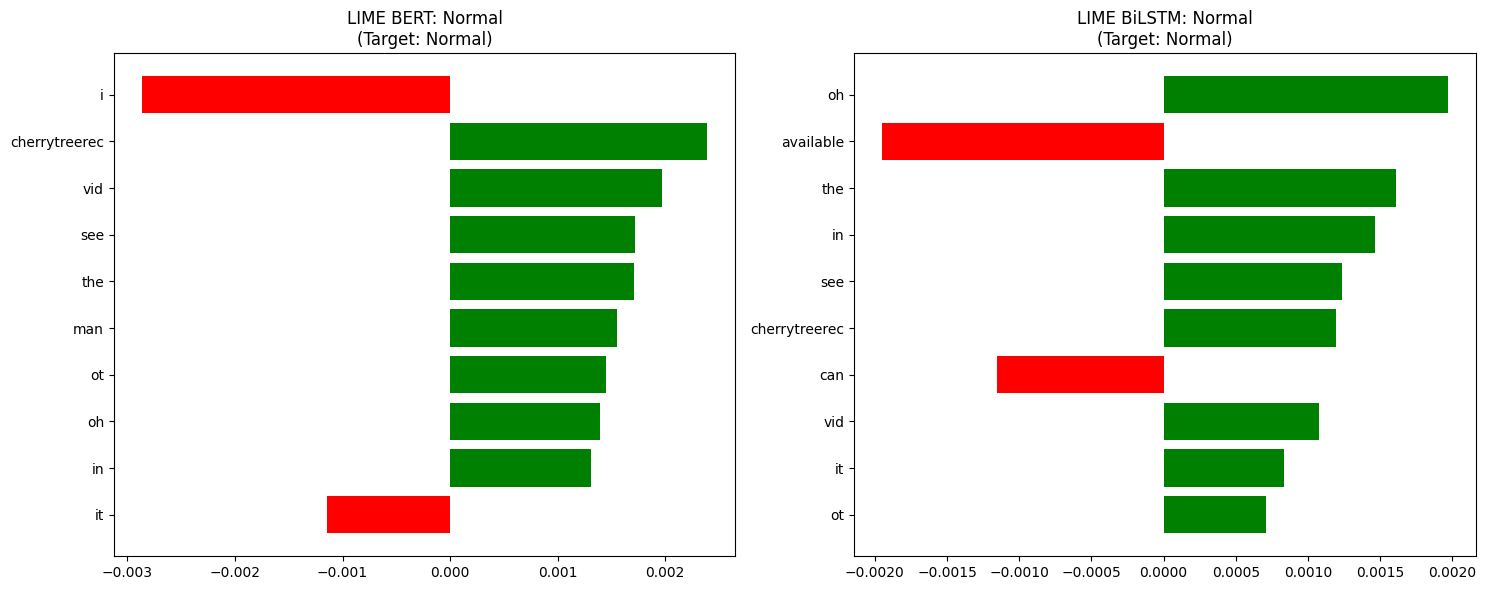


SCENARIO: Both Correct
TEXT: If so, it's good to see....
TRUE: Normal | BERT: Normal | BiLSTM: Normal

LIME BERT
  s                    ▲ INCREASES prob. (+0.0002)
  good                 ▲ INCREASES prob. (+0.0002)
  it                   ▲ INCREASES prob. (+0.0001)
  If                   ▼ DECREASES prob. (-0.0001)
  so                   ▲ INCREASES prob. (+0.0001)
  see                  ▲ INCREASES prob. (+0.0001)
  to                   ▼ DECREASES prob. (-0.0000)

LIME BiLSTM
  s                    ▲ INCREASES prob. (+0.0033)
  If                   ▼ DECREASES prob. (-0.0030)
  good                 ▲ INCREASES prob. (+0.0020)
  see                  ▲ INCREASES prob. (+0.0014)
  to                   ▼ DECREASES prob. (-0.0005)
  it                   ▲ INCREASES prob. (+0.0001)
  so                   ▲ INCREASES prob. (+0.0001)


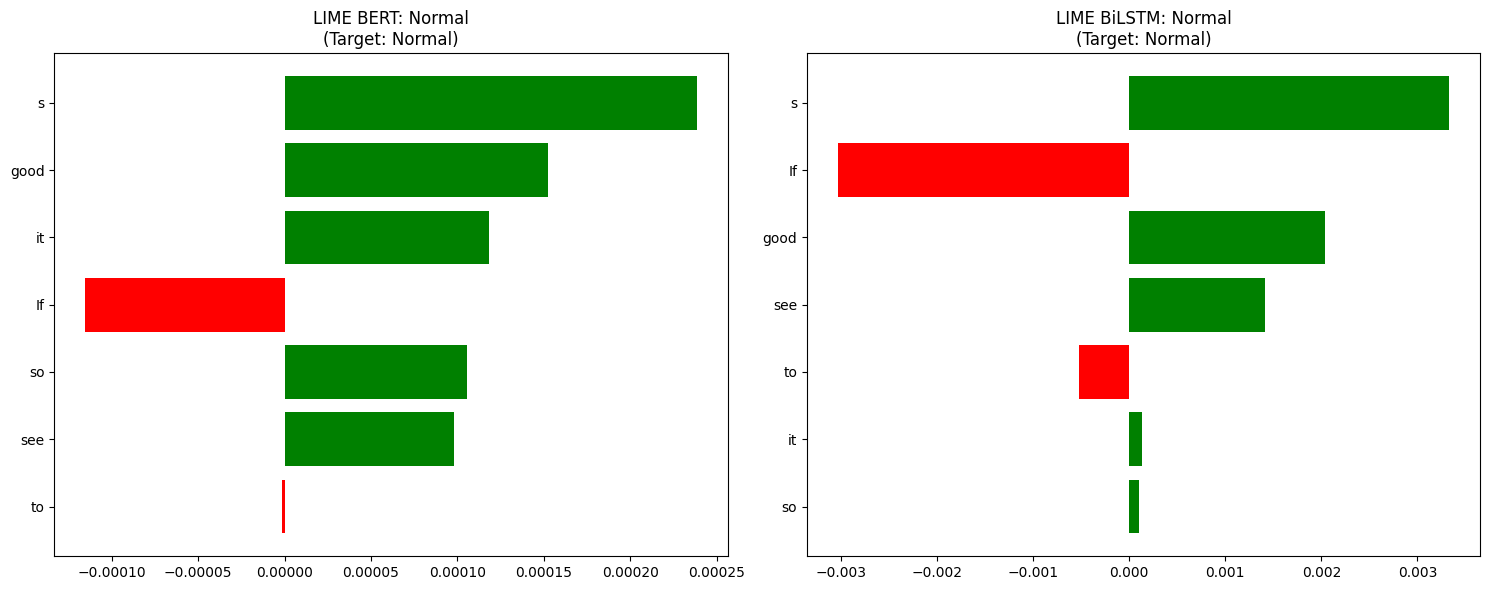


SCENARIO: Both Incorrect
TEXT: i wish people were not so cruel....
TRUE: Suicidal | BERT: Normal | BiLSTM: Normal

LIME BERT
  were                 ▲ INCREASES prob. (+0.0052)
  cruel                ▼ DECREASES prob. (-0.0051)
  so                   ▼ DECREASES prob. (-0.0037)
  people               ▼ DECREASES prob. (-0.0029)
  not                  ▲ INCREASES prob. (+0.0024)
  wish                 ▲ INCREASES prob. (+0.0009)
  i                    ▼ DECREASES prob. (-0.0007)

LIME BiLSTM
  people               ▲ INCREASES prob. (+0.0539)
  so                   ▼ DECREASES prob. (-0.0421)
  cruel                ▼ DECREASES prob. (-0.0341)
  not                  ▲ INCREASES prob. (+0.0308)
  wish                 ▼ DECREASES prob. (-0.0262)
  i                    ▼ DECREASES prob. (-0.0256)
  were                 ▼ DECREASES prob. (-0.0181)


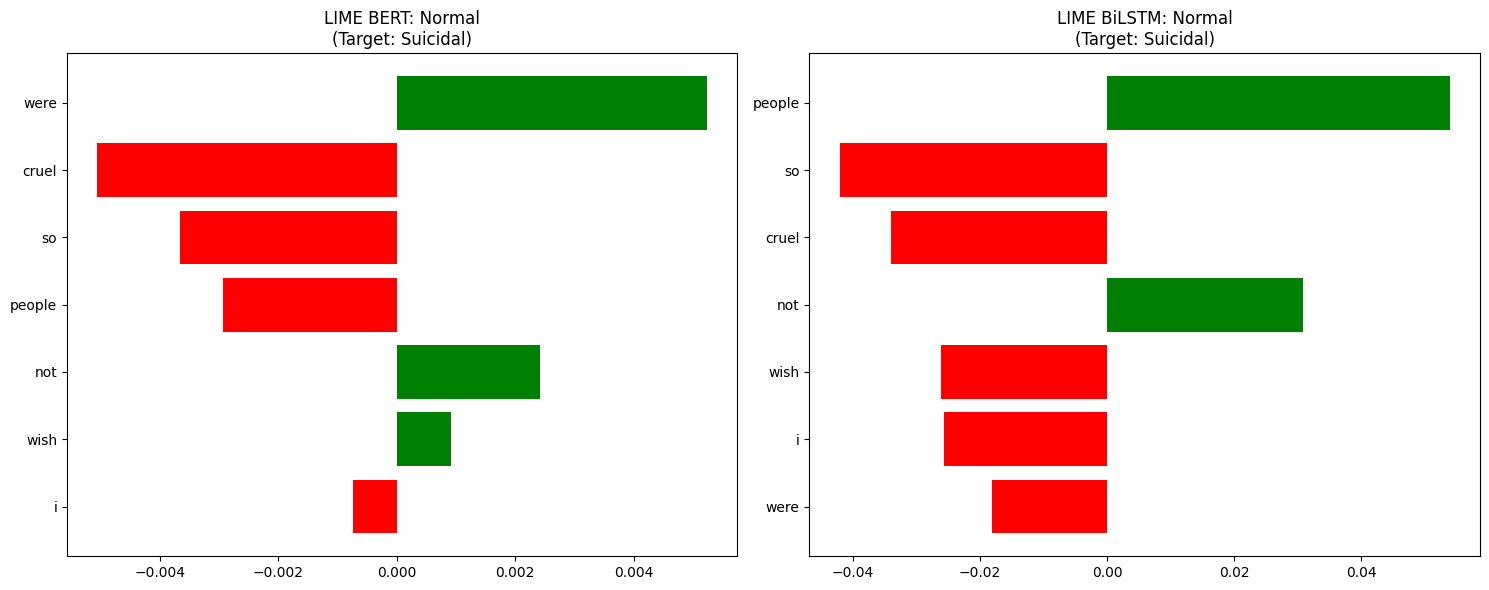


SCENARIO: Both Incorrect
TEXT: I have seen this girl for months. She was a coworker at a new place I was working.But as time went on, she decided to move somewhere else for her work, and now I rarely see her. She has not moved yet,...
TRUE: Suicidal | BERT: Depression | BiLSTM: Depression

LIME BERT
  feel                 ▲ INCREASES prob. (+0.0726)
  abandonment          ▼ DECREASES prob. (-0.0639)
  cannot               ▼ DECREASES prob. (-0.0622)
  will                 ▼ DECREASES prob. (-0.0561)
  her                  ▲ INCREASES prob. (+0.0502)
  live                 ▼ DECREASES prob. (-0.0470)
  hobbies              ▲ INCREASES prob. (+0.0452)
  unbearable           ▼ DECREASES prob. (-0.0367)
  away                 ▲ INCREASES prob. (+0.0326)
  feels                ▲ INCREASES prob. (+0.0317)

LIME BiLSTM
  feel                 ▲ INCREASES prob. (+0.2205)
  do                   ▲ INCREASES prob. (+0.1195)
  hobbies              ▲ INCREASES prob. (+0.1104)
  else                

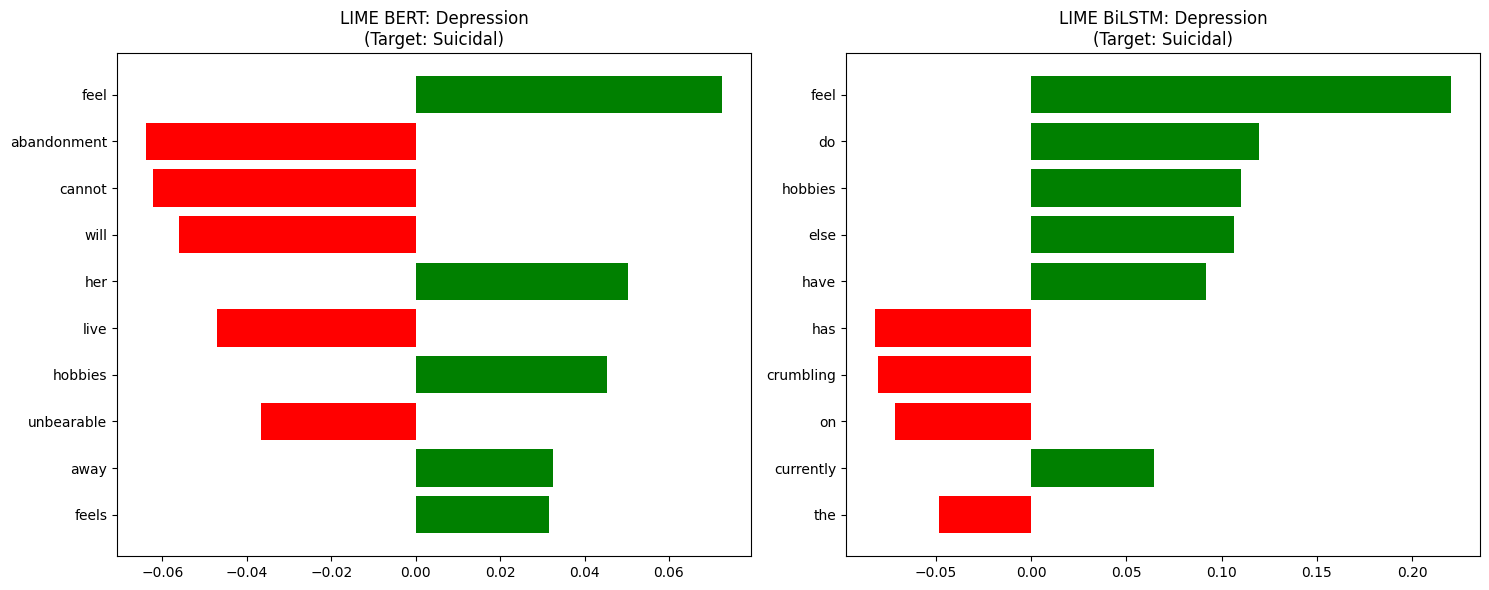


SCENARIO: BiLSTM Better
TEXT: Now I'm afraid when it comes to other people. Afraid to be wrong, afraid to make it difficult. So question yourself....
TRUE: Normal | BERT: Anxiety | BiLSTM: Normal

LIME BERT
  afraid               ▲ INCREASES prob. (+0.5763)
  Afraid               ▲ INCREASES prob. (+0.1359)
  to                   ▼ DECREASES prob. (-0.0888)
  be                   ▼ DECREASES prob. (-0.0805)
  Now                  ▼ DECREASES prob. (-0.0716)
  when                 ▲ INCREASES prob. (+0.0699)
  wrong                ▼ DECREASES prob. (-0.0661)
  I                    ▼ DECREASES prob. (-0.0651)
  difficult            ▲ INCREASES prob. (+0.0499)
  it                   ▲ INCREASES prob. (+0.0408)

LIME BiLSTM
  Now                  ▼ DECREASES prob. (-0.0152)
  yourself             ▼ DECREASES prob. (-0.0132)
  be                   ▲ INCREASES prob. (+0.0131)
  other                ▲ INCREASES prob. (+0.0118)
  to                   ▲ INCREASES prob. (+0.0104)
  I           

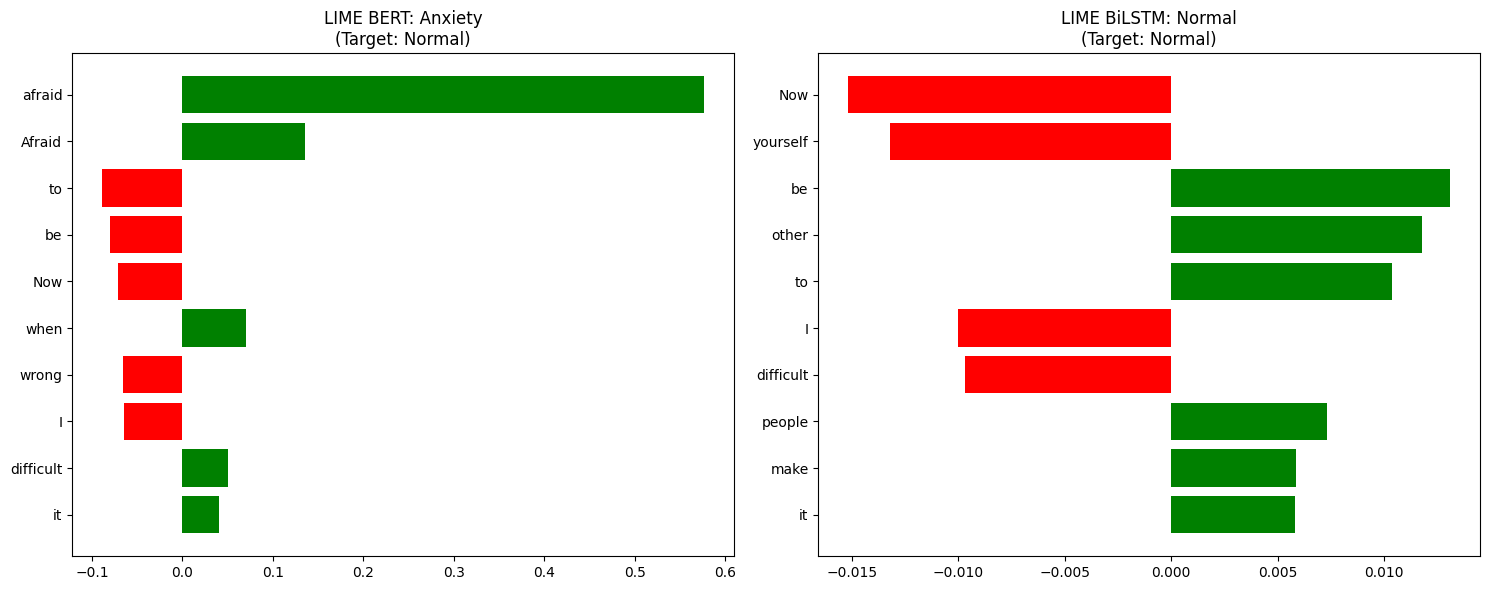


SCENARIO: BiLSTM Better
TEXT: Guys, I have been thinking a lot lately. About myself, and I am certain I hate myself because I am autistic. I feel like I have no future because of that because I am not smart. I have wasted my time ...
TRUE: Depression | BERT: Suicidal | BiLSTM: Depression

LIME BERT
  kill                 ▲ INCREASES prob. (+0.5036)
  myself               ▲ INCREASES prob. (+0.0833)
  be                   ▲ INCREASES prob. (+0.0825)
  wasted               ▲ INCREASES prob. (+0.0632)
  like                 ▼ DECREASES prob. (-0.0593)
  am                   ▲ INCREASES prob. (+0.0564)
  info                 ▲ INCREASES prob. (+0.0553)
  time                 ▲ INCREASES prob. (+0.0447)
  lately               ▼ DECREASES prob. (-0.0405)
  feel                 ▼ DECREASES prob. (-0.0160)

LIME BiLSTM
  kill                 ▼ DECREASES prob. (-0.3498)
  feel                 ▲ INCREASES prob. (+0.1204)
  myself               ▲ INCREASES prob. (+0.1044)
  been                 

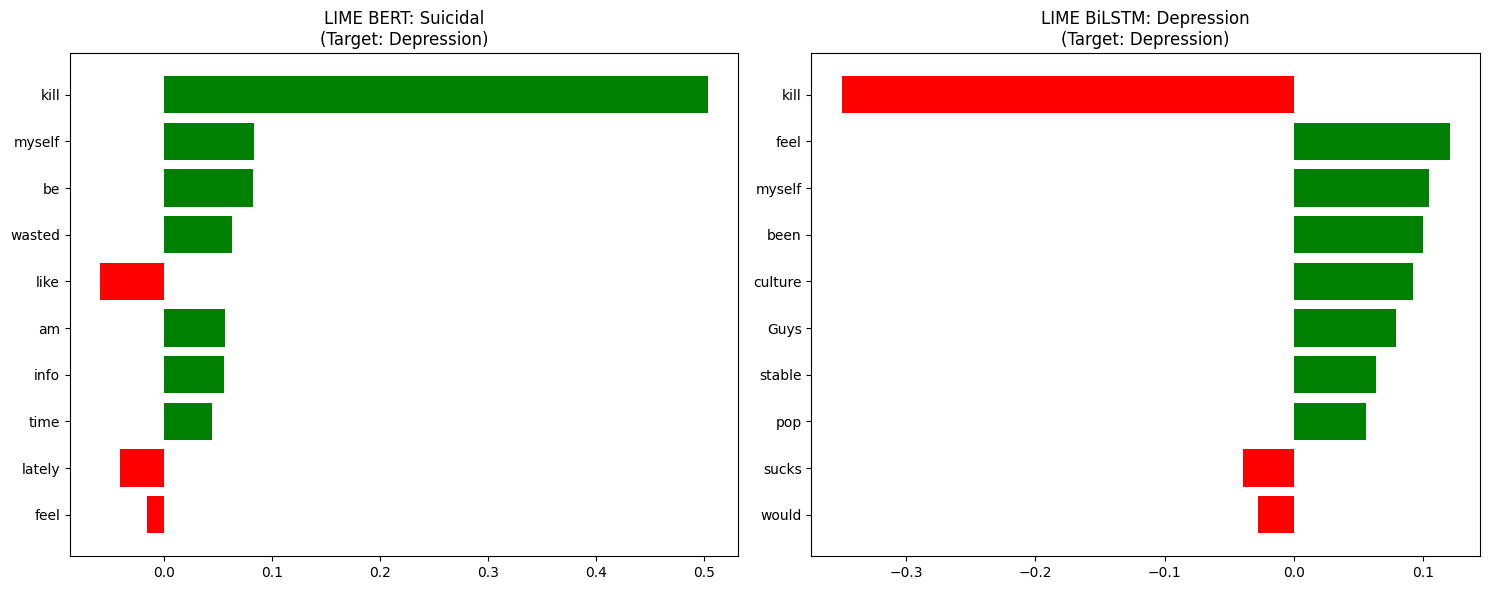


SCENARIO: BERT Better
TEXT: I don't know if it was the campground, or if the probably former friend wanted some revenge. All of the hotels are way out of our price range in our area. We can stay a couple of nights, and our reser...
TRUE: Stress | BERT: Stress | BiLSTM: Normal

LIME BERT
  terrified            ▲ INCREASES prob. (+0.3647)
  I                    ▲ INCREASES prob. (+0.2674)
  revenge              ▲ INCREASES prob. (+0.1016)
  than                 ▲ INCREASES prob. (+0.0692)
  weeks                ▲ INCREASES prob. (+0.0651)
  out                  ▲ INCREASES prob. (+0.0589)
  for                  ▲ INCREASES prob. (+0.0548)
  m                    ▲ INCREASES prob. (+0.0526)
  a                    ▲ INCREASES prob. (+0.0370)
  All                  ▲ INCREASES prob. (+0.0242)

LIME BiLSTM
  the                  ▲ INCREASES prob. (+0.0466)
  I                    ▼ DECREASES prob. (-0.0369)
  of                   ▼ DECREASES prob. (-0.0241)
  don                  ▲ INCREASES 

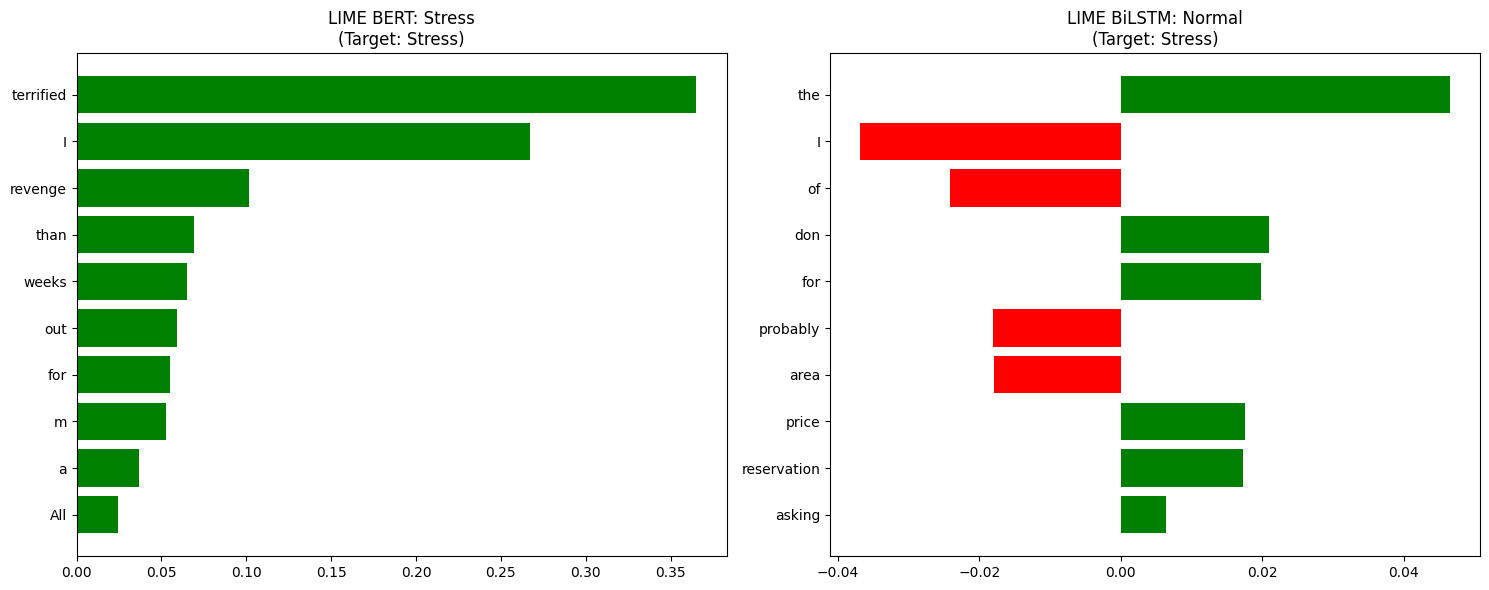


SCENARIO: BERT Better
TEXT: it is like an endless road of misery and no matter how much I try to take another path, I end up there every single time, I am completely hopeless at this point and I give up This darkness keeps getti...
TRUE: Depression | BERT: Depression | BiLSTM: Suicidal

LIME BERT
  end                  ▼ DECREASES prob. (-0.0904)
  up                   ▲ INCREASES prob. (+0.0875)
  everyday             ▲ INCREASES prob. (+0.0863)
  am                   ▼ DECREASES prob. (-0.0774)
  darker               ▲ INCREASES prob. (+0.0467)
  road                 ▼ DECREASES prob. (-0.0359)
  getting              ▲ INCREASES prob. (+0.0334)
  another              ▼ DECREASES prob. (-0.0312)
  point                ▼ DECREASES prob. (-0.0280)
  it                   ▲ INCREASES prob. (+0.0276)

LIME BiLSTM
  end                  ▲ INCREASES prob. (+0.2691)
  another              ▲ INCREASES prob. (+0.1440)
  completely           ▼ DECREASES prob. (-0.1047)
  am                   ▲ 

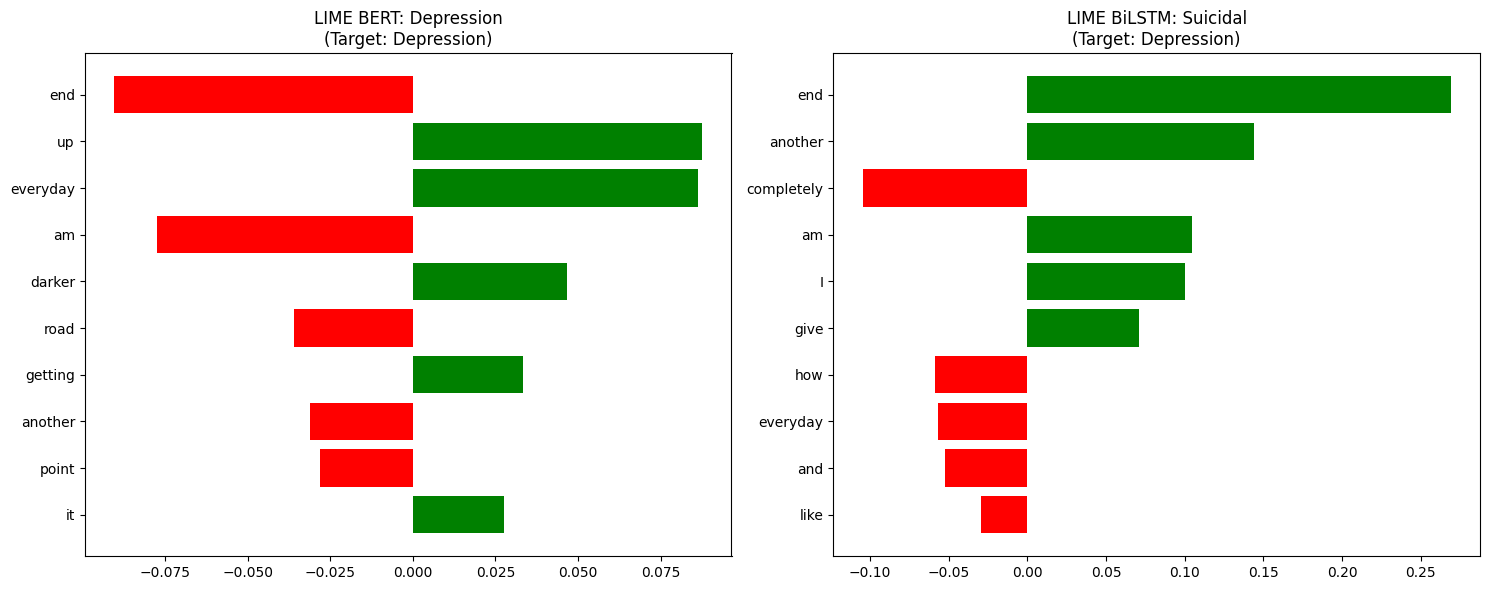

In [24]:
# Integrated comparison

# Merge predictions
df_eval_clean = df_eval.rename(columns={"pred_A": "pred_bert", "confidence": "confidence_bert"})
df_lstm_clean = df_lstm_eval.rename(columns={"true_label": "true", "pred_label": "pred_lstm", "confidence": "confidence_lstm"})

df_comparison = pd.merge(
    df_eval_clean[["text", "true", "pred_bert", "confidence_bert"]],
    df_lstm_clean[["text", "true", "pred_lstm", "confidence_lstm"]],
    on=["text", "true"]
)

# Define evaluation scenarios
scenari = {
    "Both Correct": df_comparison[(df_comparison["pred_bert"] == df_comparison["true"]) & (df_comparison["pred_lstm"] == df_comparison["true"])],
    "Both Incorrect": df_comparison[(df_comparison["pred_bert"] != df_comparison["true"]) & (df_comparison["pred_lstm"] != df_comparison["true"])],
    "BiLSTM Better": df_comparison[(df_comparison["pred_lstm"] == df_comparison["true"]) & (df_comparison["pred_bert"] != df_comparison["true"])],
    "BERT Better": df_comparison[(df_comparison["pred_bert"] == df_comparison["true"]) & (df_comparison["pred_lstm"] != df_comparison["true"])]
}

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Agreement matrix
cross_tab = pd.crosstab(df_comparison['pred_bert'], df_comparison['pred_lstm'], normalize='index') 
sns.heatmap(cross_tab, annot=True, fmt=".2f", cmap="Blues", ax=axes[0], annot_kws={"size": 9})
axes[0].set_title("Agreement Matrix (BERT vs BiLSTM)", fontsize=11)
axes[0].set_ylabel("BERT Prediction")
axes[0].set_xlabel("BiLSTM Prediction")

# Scenario distribution
data_perf = {k: len(v) for k, v in scenari.items()}
axes[1].bar(data_perf.keys(), data_perf.values(), color=['green', 'red', 'orange', 'purple'])
axes[1].set_title("Scenario Distribution", fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel("Number of samples")

plt.tight_layout()
plt.show()

# Cohen's Kappa
kappa = cohen_kappa_score(df_comparison['pred_bert'], df_comparison['pred_lstm'])
print(f"\nAgreement coefficient (Cohen's Kappa): {kappa:.4f}")

# Side-by-side LIME wrapper
def explain_side_by_side(text, true_label, pred_bert, pred_lstm, scenario):
    print(f"\nSCENARIO: {scenario}")
    print(f"TEXT: {text[:200]}...")
    print(f"TRUE: {true_label} | BERT: {pred_bert} | BiLSTM: {pred_lstm}")
    
    # LIME BERT
    print("\nLIME BERT")
    exp_bert, exp_lstm = None, None
    pred_idx_bert, pred_idx_lstm = None, None
    try:
        pred_idx_bert = np.where(le.classes_ == pred_bert)[0][0]
        exp_bert = lime_explainer.explain_instance(text, predict_proba_fn, num_features=10, num_samples=300, labels=(pred_idx_bert,))
        for word, weight in exp_bert.as_list(label=pred_idx_bert):
            direction = "▲ INCREASES prob." if weight > 0 else "▼ DECREASES prob."
            print(f"  {word:<20} {direction} ({weight:+.4f})")
    except Exception as e:
        print(f"LIME BERT error for this example: {e}")
        
    # LIME BiLSTM
    print("\nLIME BiLSTM")
    try:
        pred_idx_lstm = np.where(le.classes_ == pred_lstm)[0][0]
        exp_lstm = lime_explainer_lstm.explain_instance(text, lstm_predict_proba, num_features=10, num_samples=300, labels=(pred_idx_lstm,))
        for word, weight in exp_lstm.as_list(label=pred_idx_lstm):
            direction = "▲ INCREASES prob." if weight > 0 else "▼ DECREASES prob."
            print(f"  {word:<20} {direction} ({weight:+.4f})")
    except Exception as e:
        print(f"LIME BiLSTM error for this example: {e}")

    # Integrated side-by-side plots
    if exp_bert is not None and exp_lstm is not None:
        fig, axes_lime = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot BERT
        exp_bert_list = exp_bert.as_list(label=pred_idx_bert)
        vals_bert = [x[1] for x in exp_bert_list]
        names_bert = [x[0] for x in exp_bert_list]
        vals_bert.reverse()
        names_bert.reverse()
        colors_bert = ['green' if x > 0 else 'red' for x in vals_bert]
        pos_bert = np.arange(len(vals_bert)) + .5
        axes_lime[0].barh(pos_bert, vals_bert, align='center', color=colors_bert)
        axes_lime[0].set_yticks(pos_bert)
        axes_lime[0].set_yticklabels(names_bert)
        axes_lime[0].set_title(f"LIME BERT: {pred_bert}\n(Target: {true_label})")
        
        # Plot BiLSTM
        exp_lstm_list = exp_lstm.as_list(label=pred_idx_lstm)
        vals_lstm = [x[1] for x in exp_lstm_list]
        names_lstm = [x[0] for x in exp_lstm_list]
        vals_lstm.reverse()
        names_lstm.reverse()
        colors_lstm = ['green' if x > 0 else 'red' for x in vals_lstm]
        pos_lstm = np.arange(len(vals_lstm)) + .5
        axes_lime[1].barh(pos_lstm, vals_lstm, align='center', color=colors_lstm)
        axes_lime[1].set_yticks(pos_lstm)
        axes_lime[1].set_yticklabels(names_lstm)
        axes_lime[1].set_title(f"LIME BiLSTM: {pred_lstm}\n(Target: {true_label})")
        
        plt.tight_layout()
        plt.show()
    elif exp_bert is not None:
        fig = exp_bert.as_pyplot_figure(label=pred_idx_bert)
        fig.set_size_inches(7, 3.5)
        plt.title(f"LIME BERT: {pred_bert} (Target: {true_label})")
        plt.tight_layout()
        plt.show()
    elif exp_lstm is not None:
        fig = exp_lstm.as_pyplot_figure(label=pred_idx_lstm)
        fig.set_size_inches(7, 3.5)
        plt.title(f"LIME BiLSTM: {pred_lstm} (Target: {true_label})")
        plt.tight_layout()
        plt.show()

# Compare explanations
for nome_scenario, df_subset in scenari.items():
    if not df_subset.empty:
        # Sample scenarios
        n_samples = min(2, len(df_subset))
        samples = df_subset.sample(n=n_samples, random_state=42)
        
        for _, sample in samples.iterrows():
            explain_side_by_side(
                sample['text'], 
                sample['true'], 
                sample['pred_bert'], 
                sample['pred_lstm'],
                nome_scenario
            )

### 5.1 Confronto delle Metriche di Sintesi e Analisi Finale

Calcolo del delta delle metriche complessive (Accuracy, F1 Macro/Weighted) e visualizzazione finale tramite bar plot per classe e Radar Chart.


Metrics Comparison: DistilBERT vs BiLSTM
Metric         | DistilBERT |     BiLSTM |    Delta
Accuracy       |     0.8369 |     0.7954 |  +0.0415
F1 Macro       |     0.8225 |     0.7553 |  +0.0671
F1 Weighted    |     0.8375 |     0.7948 |  +0.0426


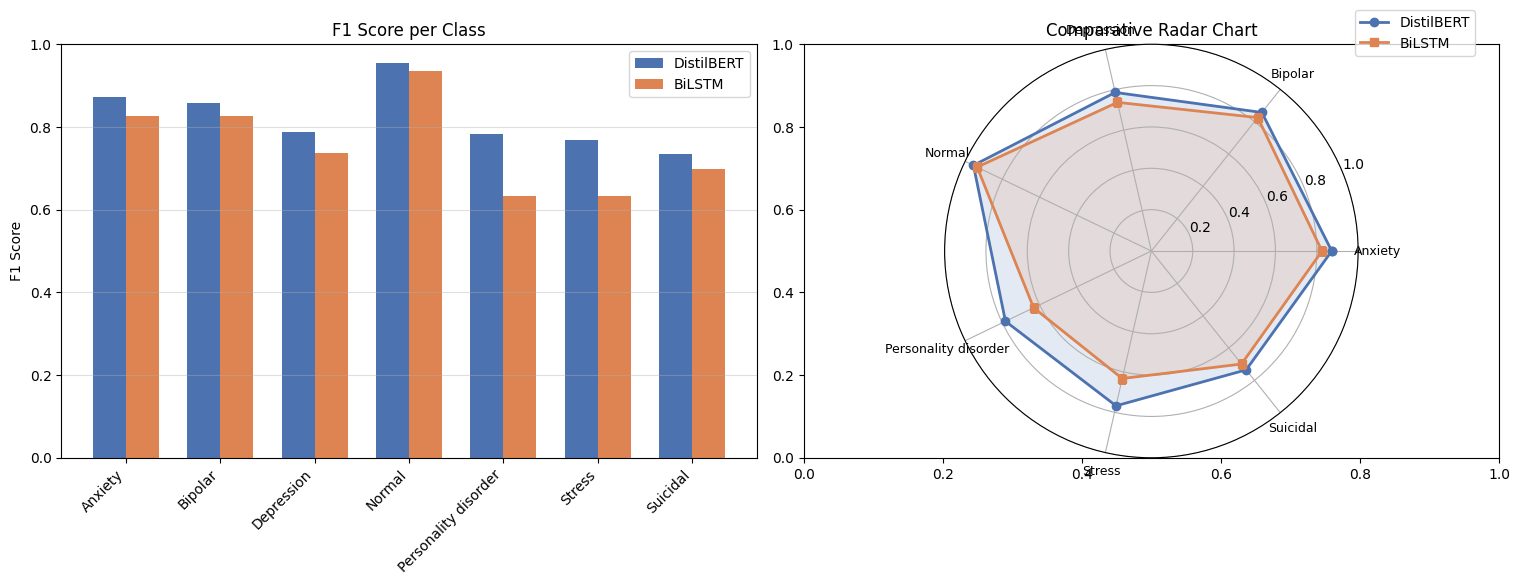

In [25]:
# Performance comparison

# Calculate metrics
summary = {
    "Accuracy"    : (accuracy_score(all_labels, all_preds), accuracy_score(lstm_labels_all, lstm_preds_all)),
    "F1 Macro"    : (f1_score(all_labels, all_preds, average="macro"), f1_score(lstm_labels_all, lstm_preds_all, average="macro")),
    "F1 Weighted" : (f1_score(all_labels, all_preds, average="weighted"), f1_score(lstm_labels_all, lstm_preds_all, average="weighted")),
}

# Print metrics table
print("Metrics Comparison: DistilBERT vs BiLSTM")
print(f"{'Metric':<14} | {'DistilBERT':>10} | {'BiLSTM':>10} | {'Delta':>8}")
for name, (db, lstm) in summary.items():
    print(f"{name:<14} | {db:>10.4f} | {lstm:>10.4f} | {db - lstm:>+8.4f}")

# Get per-class metrics
db_f1_cls   = f1_score(all_labels, all_preds, average=None, labels=range(num_labels))
lstm_f1_cls = f1_score(lstm_labels_all, lstm_preds_all, average=None, labels=range(num_labels))
classes     = le.classes_

# Radar chart setup
angles = np.linspace(0, 2 * np.pi, len(classes), endpoint=False).tolist()
angles += angles[:1] 
db_vals = db_f1_cls.tolist() + [db_f1_cls[0]]
lstm_vals = lstm_f1_cls.tolist() + [lstm_f1_cls[0]]

# Plot comparison graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Per-class F1-score
x, w = np.arange(len(classes)), 0.35
ax1.bar(x - w/2, db_f1_cls, w, label="DistilBERT", color="#4C72B0")
ax1.bar(x + w/2, lstm_f1_cls, w, label="BiLSTM", color="#DD8452")
ax1.set_xticks(x)
ax1.set_xticklabels(classes, rotation=45, ha="right")
ax1.set_ylim(0, 1)
ax1.set_ylabel("F1 Score")
ax1.set_title("F1 Score per Class")
ax1.legend()
ax1.grid(axis="y", alpha=0.4)

# Radar chart
ax2 = plt.subplot(122, polar=True)
ax2.plot(angles, db_vals, "o-", color="#4C72B0", linewidth=2, label="DistilBERT")
ax2.fill(angles, db_vals, alpha=0.15, color="#4C72B0")
ax2.plot(angles, lstm_vals, "s-", color="#DD8452", linewidth=2, label="BiLSTM")
ax2.fill(angles, lstm_vals, alpha=0.15, color="#DD8452")
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(classes, fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_title("Comparative Radar Chart")
ax2.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()